In [1]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

import os
import git_root
from src.utils import *

# Dynamical Critical Exponent from Normal Mode Time Series

One method of extracting the dynamical critical exponent (DCE) from the multi-species exclusion process is to apply topological data analysis directly to the hydrodynamic normal modes since we know from our previous experimentatoin that the hydrodynamic normal mode time series if effective in splitting the process into its different regimes. The function `normal_mode_height_time_series` returns a time series of these modes in the form

$$H(t,x,m)$$

where $t$ is time, $x$ is the spatial position, and $m$ labels the hydrodynamic mode. For a fixed mode $m$, each time slice gives a spatial height profile

$$h_m(t,x)$$

However at a certain time $t$ this is just a one dimensional data point with no topological features so we construct a topological observable from the shape of this profile. At each time $t$, the spatial profile is converted into a point cloud by taking local patches of length $w$. Each patch becomes one point:

$$\big(h_m(t,x), h_m(t,x+1), \ldots, h_m(t,x+w-1)\big)$$

$$\big(h_m(t,x+1), h_m(t,x+2), \ldots, h_m(t,x+w)\big)$$

$$\big(h_m(t,x+2), h_m(t,x+3), \ldots, h_m(t,x+w+1)\big)$$

$$\vdots$$

Thus, a single height profile produces a point cloud in $\mathbb{R}^w$. This point cloud represents the collection of local spatial patterns appearing in the hydrodynamic mode at that time.

The key idea is that if the hydrodynamic mode relaxes slowly, then the topology of its patch cloud should also retain memory for a long time. Therefore, we compute the autocorrelation of the topological observable,

$$C_O(\Delta t) \langle O(t)O(t+\Delta t)\rangle_t$$

and extract a relaxation time $\tau_{\mathrm{TDA}}(L)$. This relaxation time can be defined as the first time the autocorrelation drops below $1/e$, or as the integrated autocorrelation time up to the first zero crossing.

In [2]:
L_values = np.arange(240, 600, 15)

rates_matrix = 1 - np.diag((1, 1, 1)) # both diffusive
# rates_matrix = np.triu(np.ones((3, 3), dtype=np.float64), k=1) # both kpz

mode_index = 0

n_samples = 6000
sample_every = 25

patch_divisor = 8
patch_stride = 1

N_runs = 4
tda_every = 2

taus = []

Note the following simulation may take upwards of $10 \frac 12$ hours to run on the Purdue Negishi & Bell supercomputers, below will outline how to submit the job on engines through slurm to speed up computation to at least `NUM_ENGINES` fold.

In [3]:
checkpoint_path = f"{git_root.git_root()}/data/slurm_jobs/h0_total_persistance_slow_run_notebook.npz"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

if os.path.exists(checkpoint_path):
    data = np.load(checkpoint_path, allow_pickle=True)

    old_L_values = data["L_values"]
    taus = list(data["taus"])
    done = data["done"].astype(bool)

    print("Loaded checkpoint:", checkpoint_path)
    print(f"Completed L values: {np.sum(done)} / {len(L_values)}")

else:
    taus = [np.nan for _ in L_values]
    done = np.zeros(len(L_values), dtype=bool)

    print("Starting new checkpoint:", checkpoint_path)

Loaded checkpoint: /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h0_total_persistance_slow_run_notebook.npz
Completed L values: 24 / 24


In [4]:
for L_index, L in enumerate(tqdm(L_values, smoothing=0)):
    if done[L_index]:
        continue

    tau_runs = []

    for run_id in range(N_runs):
        process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=int(L))

        H = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)

        patch_window = max(8, int(L) // patch_divisor)

        n_times = H.shape[0]
        tda_indices = np.arange(0, n_times, tda_every)

        h0_series = np.zeros(len(tda_indices), dtype=float)

        for j, t in enumerate(tda_indices):
            h_profile = H[t, :, mode_index]

            points = patch_point_cloud(h_profile, window=patch_window, stride=patch_stride)

            series[j] = h0_total_persistence(points) # this observable can be replaced by any TDA observable

        C = autocorrelation(series)

        times = np.arange(len(C)) * sample_every * tda_every
        tau = relaxation_time(C, times)

        tau_runs.append(tau)

    tau_mean = np.nanmean(tau_runs)

    taus[L_index] = tau_mean
    done[L_index] = True

    np.savez(checkpoint_path, L_values=L_values, taus=np.asarray(taus, dtype=float), done=done)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 318554.73it/s]


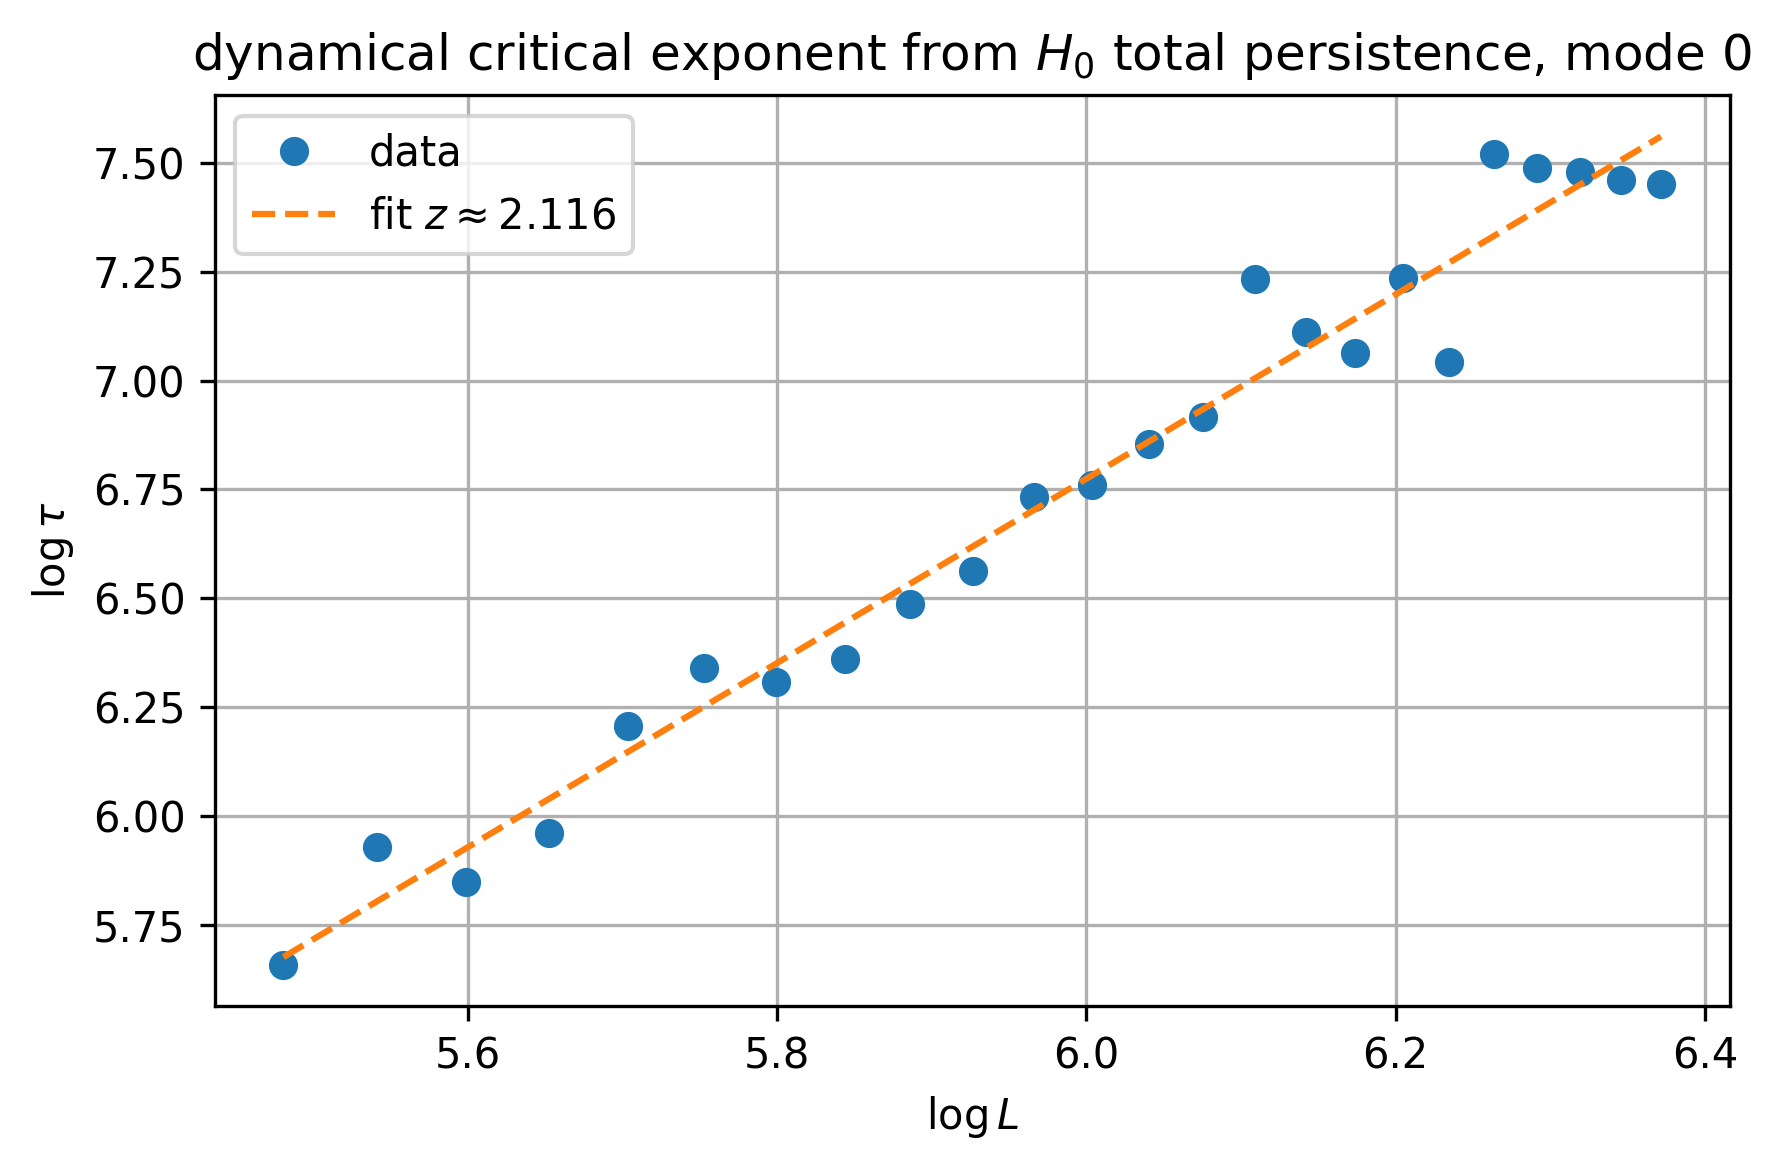

In [5]:
taus = np.array(taus)
valid = np.isfinite(taus) & (taus > 0)

logL = np.log(L_values[valid])
logtau = np.log(taus[valid])

z, intercept = np.polyfit(logL, logtau, 1)
fit = intercept + z * logL

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(logL, logtau, "o", label="data")
plt.plot(logL, fit, "--", label=fr"fit $z \approx {z:.3f}$")

plt.xlabel(r"$\log L$")
plt.ylabel(r"$\log \tau$")
plt.title(fr"dynamical critical exponent from $H_0$ total persistence, mode {mode_index}")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

## Using `ipyparallel` to Speed Up the TDA Computation on Purdue Negishi & Bell Clusters

The $H_0$ persistence calculation is expensive because we repeat the same full procedure for many system sizes $L$: simulate the process, compute the normal-mode height time series, build patch point clouds, compute $H_0$ persistence, compute the autocorrelation, and extract a relaxation time. 

Each value of $L$ is independent of the others, so this is an ideal place to use parallel computing. With `ipyparallel`, we start an IPython cluster with several engines where each engine is basically a separate Python worker process running on one CPU core. 

If we start $N$ engines, then up to $N$ different $L$ values can be computed at the same time instead of one after another. This does not make a single $L$-calculation faster, but it makes the full sweep over many $L$ values much faster.

In [6]:
import time
import subprocess
import ipyparallel as ipp
from collections import defaultdict

Below the code resets and starts the IPyParallel controller (the central process the notebook talks to). The controller doesn't do heavy computation itself, it talks between the notebook and the IPyParallel engines that will later run on the Slurm compute node.

First, it chooses the IPyParallel profile named `"default"`. The profile tells IPyParallel where to store and look for connection files, logs, and security information. Note the notebook, controller, and engines all need to use the same profile so they can find each other. Then it kills any old `ipcontroller` or `ipengine` processes owned by `$USER`. This is done to avoid accidentally connecting to stale controllers or old engines from a previous attempt. 

Then it starts a fresh ipcontroller with the `"default"` profile. The flag `--ip='*'` allows engines from other machines, such as Slurm compute nodes, to connect back to this controller, the flag `--log-to-file` saves controller logs, and the flag `--log-level=20` keeps logs caped at 20. Note `&` at the end starts the controller in the background, so notebook can continue running.

Finally the notebook creates an IPyParallel client with `ipp.Client(profile=profile)`. This client connects the notebook to the controller. At this point, the controller may have zero engines connected, so `rc.ids` may print an empty list. Note that is fine the controller is ready, but the Slurm engine job still needs to start. Once the Slurm job runs ipengine processes, those engines should register with this controller.


In [7]:
profile = "default"

subprocess.call("pkill -u $USER -f ipcontroller", shell=True)
subprocess.call("pkill -u $USER -f ipengine", shell=True)
time.sleep(3)

cmd = f"ipcontroller --profile={profile} --ip='*' --log-to-file --log-level=20 &"
print("Starting controller:")
print("Command:", cmd)
subprocess.call(cmd, shell=True)

time.sleep(5)

rc = ipp.Client(profile=profile)
print("Controller connected.")
print("Current engine IDs:", rc.ids)

Starting controller:
Command: ipcontroller --profile=default --ip='*' --log-to-file --log-level=20 &


Sending logs to /home/dupreti/.ipython/profile_default/log/ipcontroller--550497.log
2026-07-04 10:25:17.273 [task] Task scheduler started [leastload]
2026-07-04 10:25:17.275 [broadcast-0] BroadcastScheduler 0 started
2026-07-04 10:25:17.277 [broadcast-00] BroadcastScheduler 00 started
2026-07-04 10:25:17.280 [broadcast-01] BroadcastScheduler 01 started
2026-07-04 10:25:17.281 [IPController] heartbeat::waiting for subscription
2026-07-04 10:25:17.281 [IPController] heartbeat::subscription started


Controller connected.
Current engine IDs: []


This will display the number of cores avalible on the `physics` account of the Purdue Negishi & Bell Clusters.

In [8]:
cmd_slist_cores = """slist | awk '$1 == "physics" {print $6}'"""
slist_cores_result = subprocess.run(cmd_slist_cores, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
CORES_AVALIBLE = int(slist_cores_result.stdout)

print("Cores avalible:", CORES_AVALIBLE)

Cores avalible: 128


This submits the Slurm job that will start the IPyParallel engines on the cluster. 

In [9]:
N_ENGINES = 24 # add max the numbers of cores avalible or else will sit in queue. 

# WALLTIME = "336:00:00" # 14 Day - Maximum Limit on Purdue Negishi & Bell Clusters
WALLTIME = "168:00:00" # 7 Days

repo = git_root.git_root()
cmd = f"sbatch --ntasks={N_ENGINES} --time={WALLTIME} {git_root.git_root()}/scripts/start_ipengines.sh"

result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

print("Command:", cmd)
print("STDOUT:", result.stdout)
if (result.stderr != ""):
    print("STDERR:", result.stderr)
print("Return code:", result.returncode)

Command: sbatch --ntasks=24 --time=168:00:00 /home/dupreti/TDA-Diffusion-Models/scripts/start_ipengines.sh
STDOUT: Submitted batch job 40178221

Return code: 0


This reconnects the notebook to the IPyParallel controller and then waits until the Slurm launched engines have registered with it.

In [10]:
rc = ipp.Client(profile="default") # creates client connected to IPyParallel controller with "default" profile
print("Initial IDs:", rc.ids) # which engines are already connected at that moment

rc.wait_for_engines(N_ENGINES, timeout=86400) # pause until 24 engines have connected or 24 hour timeout 

print("Final IDs:", rc.ids)
print("Number of engines:", len(rc.ids)) # must match number of engines

Initial IDs: []


  0%|          | 0/24 [00:00<?, ?engine/s]

Final IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of engines: 24


2026-07-04 10:25:50.285 [IPController] Notifying hub of 24 new hearts


This prepares all of the IPyParallel engines so they can import the project code correctly.

In [11]:
dview = rc[:]
lbview = rc.load_balanced_view()

This code pushes list of function names to parallel background processing engines (via `ipyparallel` direct view, `dview`) to ensure the remote workers have access to these notebook functions when running parallel tasks.

In [12]:
def push_functions_to_engines(*function_names):
    funcs = {}

    for name in function_names:
        if name not in globals():
            raise NameError(f"{name} is not defined in the notebook kernel.")

        funcs[name] = globals()[name]

    dview.push(funcs, block=True)

    print("Pushed functions to engines:")
    for name in function_names:
        print("  ", name)

imports libraries parallelly across all active `ipyparallel` background engines.

In [13]:
%%px

import os
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from src.utils import *

%px:   0%|          | 0/24 [00:00<?, ?tasks/s]

This function splits your the number of simulation runs (`n_runs`) into a chosen number of batches (`n_batches`).

In [14]:
def split_run_ids(n_runs, n_batches):
    n_batches = min(int(n_batches), int(n_runs))

    batches = []
    for batch_index in range(n_batches):
        start = batch_index * n_runs // n_batches
        end = (batch_index + 1) * n_runs // n_batches
        batches.append(list(range(start, end)))

    return batches

This function computes the relaxation time `tau` for one independent simulation run at a fixed system size `L`.

In [15]:
def compute_tau_single_run(L, observable_name, process_name, run_id, **observable_kwargs):
    rates_matrix = np.array([[0.0, 1.0, 0.1], [1.0, 0.0, 0.1], [2.1, 2.1, 0.0]])  # one KPZ mode, one diffusive mode

    observable_function = globals()[observable_name]

    mode_indices = [0, 1]

    n_samples = 6000
    sample_every = 25

    patch_divisor = 8
    patch_stride = 1
    tda_every = 2

    patch_window = max(8, int(L) // patch_divisor)

    # Optional reproducible seed.
    # seed = 10_000_000 + 1000 * int(L) + int(run_id)
    # np.random.seed(seed)

    process = MultiSpeciesExclusionProcess(dimension=3, density=[1/3, 1/3, 1/3], rates_matrix=rates_matrix, length=int(L))

    H = process.normal_mode_height_time_series(n_samples=n_samples, sample_every=sample_every)

    n_times = H.shape[0]
    tda_indices = np.arange(0, n_times, tda_every)

    taus_for_modes = []

    for mode_index in mode_indices:
        series = np.zeros(len(tda_indices), dtype=float)

        for j, t in enumerate(tda_indices):
            h_profile = H[t, :, mode_index]

            points = patch_point_cloud(h_profile, window=patch_window, stride=patch_stride)

            series[j] = observable_function(points, **observable_kwargs)

        C = autocorrelation(series)
        times = np.arange(len(C)) * sample_every * tda_every

        tau = relaxation_time(C, times)

        taus_for_modes.append(tau)

    return taus_for_modes

Note that `compute_tau_for_L_batch` computes a partial group of runs for one fixed system size `L`. Instead of doing just one simulation, it takes a list of `run_ids`, runs `compute_tau_single_run` once for each of those IDs, and collects the resulting relaxation times for the two modes. At the end, it does not directly return the average. Instead, it returns the sum of the valid tau values and the number of valid tau values for each mode. This is useful for parallelization because different engines can each compute a different batch of runs for the same L, return their partial sums and counts, and then the main code can combine those pieces later to get the final average.

`compute_tau_for_L` just sets up the full list of 24 run IDs, sends all of them to `compute_tau_for_L_batch`, and then divides the returned `tau` sums by the `tau` counts to get the final average relaxation time for each mode at that system size.

In [16]:
def compute_tau_for_L_batch(L, observable_name, process_name="tda_observable", run_ids=None, observable_kwargs=None):
    if run_ids is None:
        run_ids = [0]

    if observable_kwargs is None:
        observable_kwargs = {}

    all_taus = []

    for run_id in run_ids:
        taus_for_modes = compute_tau_single_run(L=L, observable_name=observable_name, process_name=process_name, run_id=run_id, **observable_kwargs)

        all_taus.append(taus_for_modes)

    all_taus = np.asarray(all_taus, dtype=float)

    tau_sum = np.nansum(all_taus, axis=0)
    tau_count = np.sum(np.isfinite(all_taus), axis=0)

    return int(L), tau_sum, tau_count

In [17]:
def compute_tau_for_L(L, observable_name, process_name="tda_observable", observable_kwargs=None):
    if observable_kwargs is None:
        observable_kwargs = {}

    N_runs = 24
    run_ids = list(range(N_runs))

    L, tau_sum, tau_count = compute_tau_for_L_batch(L=L, observable_name=observable_name, process_name=process_name, run_ids=run_ids, observable_kwargs=observable_kwargs)

    with np.errstate(invalid="ignore", divide="ignore"):
        tau_means = tau_sum / tau_count

    return int(L), tau_means

This `engine_loop` function is the main driver that runs the TDA relaxation time computation across many system sizes using all available `ipyparallel` engines. It first defines the range of `L` values, sets up a checkpoint file for saving completed results, and checks whether any `L` values have already been finished so the job can resume instead of starting over. 

If everything is already complete, it simply loads the saved `tau` values and returns them. Otherwise, it looks at how many engines are connected and decides how to divide the work: if there are fewer engines than unfinished `L` values, each engine gets one full `L` job; if there are more engines than `L` values, each `L` is split into several batches of runs so the extra engines can still be used. It then builds a list of run-batch tasks, sends those tasks to the engines, and collects the partial tau sums and counts as each batch finishes. Once all batches fora particul are `L` are done, it averages the valid `tau` values for that `L` and saves the result to the checkpoint. This means the computation can survive interruptions and does not need to redo finished system sizes.

In [18]:
def engine_loop(process_name, observable_name, delete_checkpoint_when_done=False, n_runs_total=24, **observable_kwargs,):
    start = 240
    end = 600
    step = 15
    
    L_values = np.arange(start, end, step)

    safe_process_name = safe_name(process_name) + "_notebook"

    output_dir = f"{git_root.git_root()}/data/slurm_jobs"

    checkpoint = LCheckpoint(process_name=safe_process_name, L_values=L_values, n_outputs=2, output_dir=output_dir)

    checkpoint.install_signal_handlers()
    checkpoint.print_status()

    remaining_L_values = checkpoint.remaining_L_values()

    if len(remaining_L_values) == 0:
        print("all L values already completed; loading taus from checkpoint")

        taus = np.array(checkpoint.get_results())

        if delete_checkpoint_when_done and checkpoint.is_complete():
            checkpoint.delete()

        return L_values, taus

    n_engines = len(rc.ids)

    if n_engines == 0:
        raise RuntimeError("No ipyparallel engines are connected.")

    n_unfinished_L = len(remaining_L_values)

    # If engines <= L values, use one batch per L.
    # If engines > L values, split each L into multiple run batches.
    if n_engines <= n_unfinished_L:
        batches_per_L = 1
    else:
        batches_per_L = math.ceil(n_engines / n_unfinished_L)

    batches_per_L = min(batches_per_L, n_runs_total)

    print(f"connected engines: {n_engines}")
    print(f"unfinished L values: {n_unfinished_L}")
    print(f"runs per L: {n_runs_total}")
    print(f"batches per L: {batches_per_L}")

    task_L_values = []
    task_observable_names = []
    task_process_names = []
    task_run_id_batches = []
    task_observable_kwargs = []

    for L in remaining_L_values:
        run_id_batches = split_run_ids(n_runs=n_runs_total, n_batches=batches_per_L)

        for run_ids in run_id_batches:
            task_L_values.append(int(L))
            task_observable_names.append(observable_name)
            task_process_names.append(safe_process_name)
            task_run_id_batches.append(run_ids)
            task_observable_kwargs.append(observable_kwargs)

    n_tasks = len(task_L_values)

    print(f"sending {n_tasks} run-batch jobs to {n_engines} engines...")

    async_result = lbview.map_async(compute_tau_for_L_batch, task_L_values, task_observable_names, task_process_names, task_run_id_batches, task_observable_kwargs)

    tau_sums_by_L = defaultdict(lambda: np.zeros(2, dtype=float))
    tau_counts_by_L = defaultdict(lambda: np.zeros(2, dtype=float))
    finished_batches_by_L = defaultdict(int)

    expected_batches_by_L = {int(L): batches_per_L for L in remaining_L_values}

    for L, tau_sum, tau_count in tqdm(async_result, total=n_tasks, desc="finished run-batch jobs"):
        L = int(L)

        tau_sum = np.asarray(tau_sum, dtype=float)
        tau_count = np.asarray(tau_count, dtype=float)

        tau_sums_by_L[L] += tau_sum
        tau_counts_by_L[L] += tau_count
        finished_batches_by_L[L] += 1

        # Only checkpoint an L once all its run batches have finished.
        if finished_batches_by_L[L] == expected_batches_by_L[L]:
            with np.errstate(invalid="ignore", divide="ignore"):
                tau_means = tau_sums_by_L[L] / tau_counts_by_L[L]

            checkpoint.record(L=L, values=tau_means, autosave=True)

    print("computation finished")

    taus = np.array(checkpoint.get_results())

    if delete_checkpoint_when_done and checkpoint.is_complete():
        checkpoint.delete()

    return L_values, taus

This function plots the `L_values` against the `taus` to extract the dynamical critical exponent.

In [19]:
def plot(L_values, taus, process_name):
    taus = np.array(taus)

    plt.figure(figsize=(6.5, 4.5), dpi=300)

    for mode_index in [0, 1]:
        taus_mode = taus[:, mode_index]

        valid = np.isfinite(taus_mode) & (taus_mode > 0)

        logL = np.log(L_values[valid])
        logtau = np.log(taus_mode[valid])

        z, intercept = np.polyfit(logL, logtau, 1)
        fit = intercept + z * logL

        plt.plot(logL, logtau, "o", markersize=4, label=fr"mode {mode_index} data")
        plt.plot(logL, fit, "--", linewidth=1.5, label=fr"mode {mode_index} fit, $z \approx {z:.3f}$")

        print(f"mode {mode_index}: z = {z}")

    plt.xlabel(r"$\log L$", fontsize=12)
    plt.ylabel(r"$\log\tau$", fontsize=12)
    plt.title(fr"dynamical critical exponent from {process_name}", fontsize=14)

    plt.legend(fontsize=9, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [20]:
push_functions_to_engines("compute_tau_single_run", "compute_tau_for_L_batch", "compute_tau_for_L")

Pushed functions to engines:
   compute_tau_single_run
   compute_tau_for_L_batch
   compute_tau_for_L


## Strongly Coupled Topological Observables

The following observables are shown to have strong 

### $H_0$ Total Persistence

$H_0$ persistence means measuring how the connected components of a point cloud merge together as the filtration scale grows. At the beginning, every point is its own separate connected component. As the radius/filtration value increases, nearby points become connected, and separate components merge into larger components. Each $H_0$ feature has a birth time and a death time: the `birth` is usually when the component first appears, and the `death` is when that component merges into another component. The persistence lifetime is `death - birth`, which measures how long that connected component survived before merging.

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h0_total_persistence_notebook.npz
Completed L jobs: 24 / 24
h0_total_persistence_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.9603481899987425
mode 1: z = 1.4876102685283634


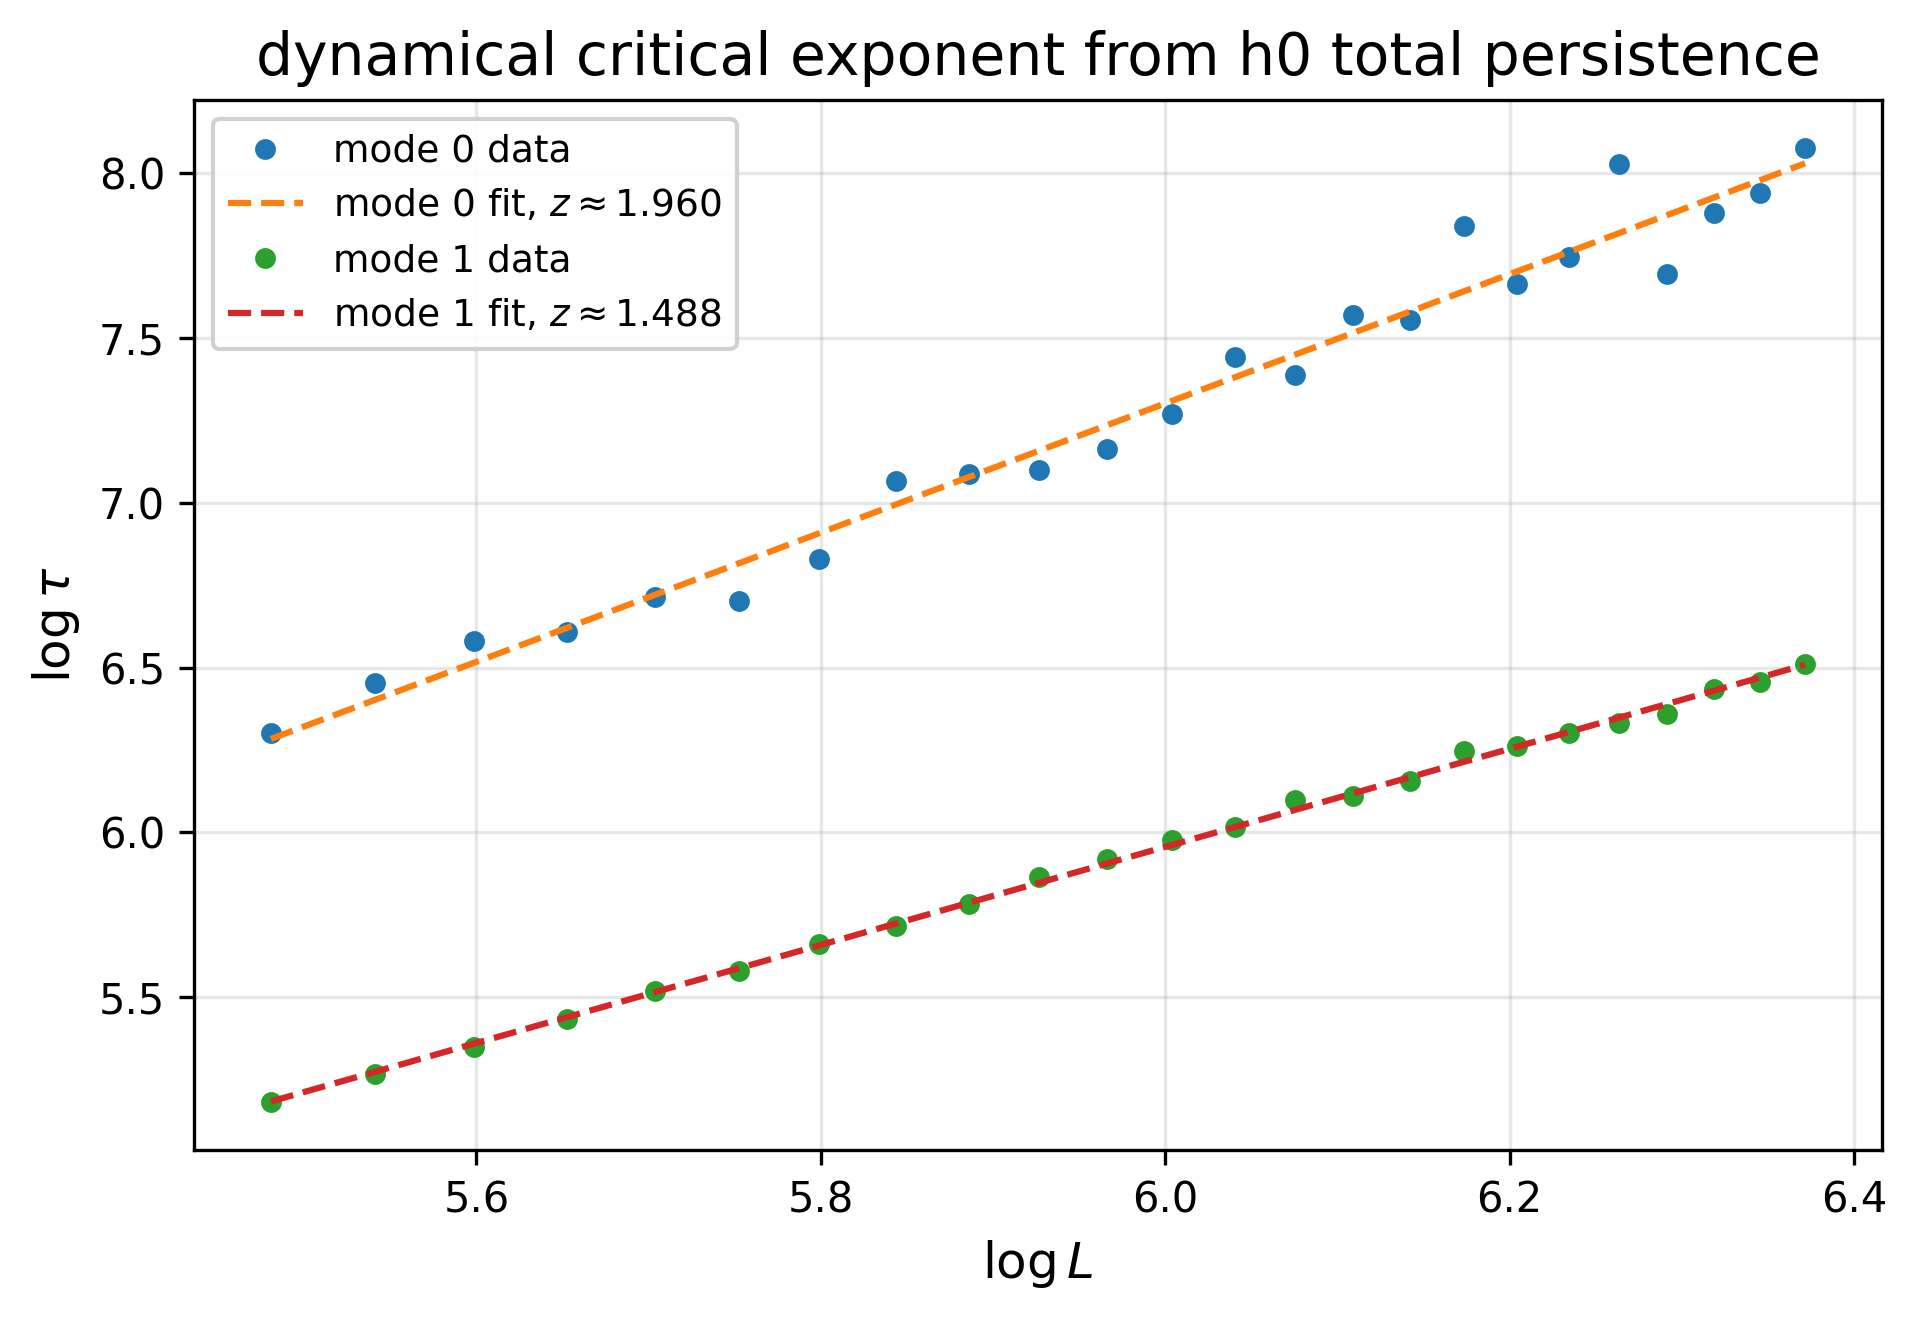

In [21]:
observable_name = "h0_total_persistence_from_points"
process_name = "h0 total persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_0$ Maximum Persistence

Maximum $H_0$ persistence is similar to total $H_0$ persistence, but instead of adding up all the connected component lifetimes, it only keeps the largest one. In an $H_0$ persistence diagram, each finite lifetime tells how long one connected component survived before it merged into another component as the filtration scale increased. Most components may die quickly because they are close to other points, but a component with a large lifetime stayed separate for a relatively long time. So this function computes all finite $H_0$ lifetimes and returns the biggest one.

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h0_maximum_persistence_notebook.npz
Completed L jobs: 24 / 24
h0_maximum_persistence_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.9341234913992198
mode 1: z = 1.4978867492747008


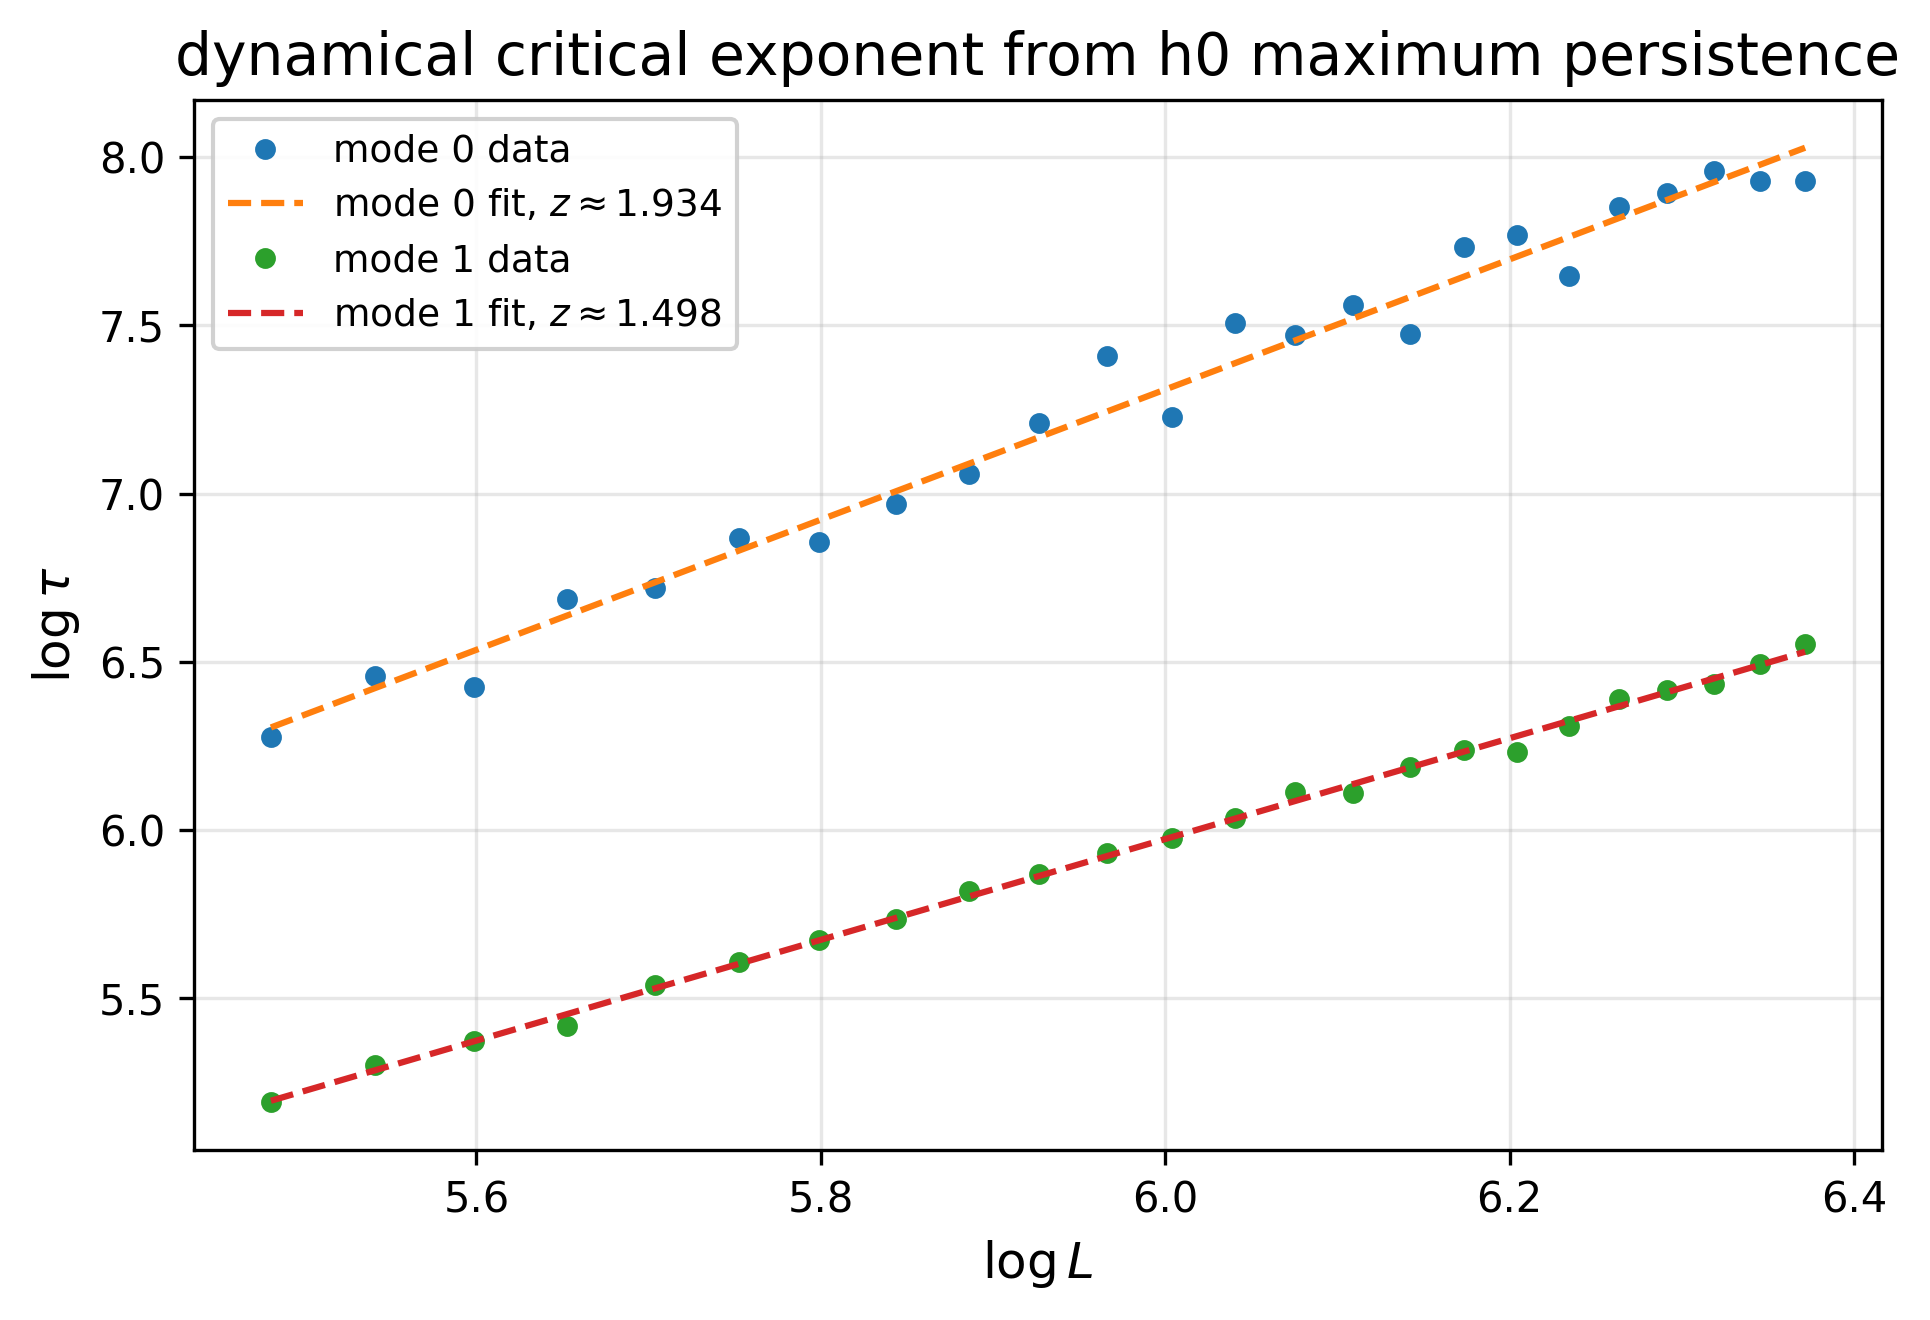

In [22]:
observable_name = "h0_max_persistence_from_points"
process_name = "h0 maximum persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_1$ Total Persistence

$H_1$ total persistence measures the total strength of loop like structure in a point cloud. While $H_0$ looks at connected components, $H_1$ looks at 1D holes or loops. As the filtration scale grows, points begin connecting into edges, and sometimes those edges form loops. Later, when the scale gets large enough, those loops get filled in and disappear. Each $H_1$ feature therefore has a lifetime: how long that loop exists before it dies. This function computes the $H_1$ persistence diagram, extracts all finite positive lifetimes, and sums them.

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h1_total_persistence_notebook.npz
Completed L jobs: 24 / 24
h1_total_persistence_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.9517967808428103
mode 1: z = 1.4884934787381572


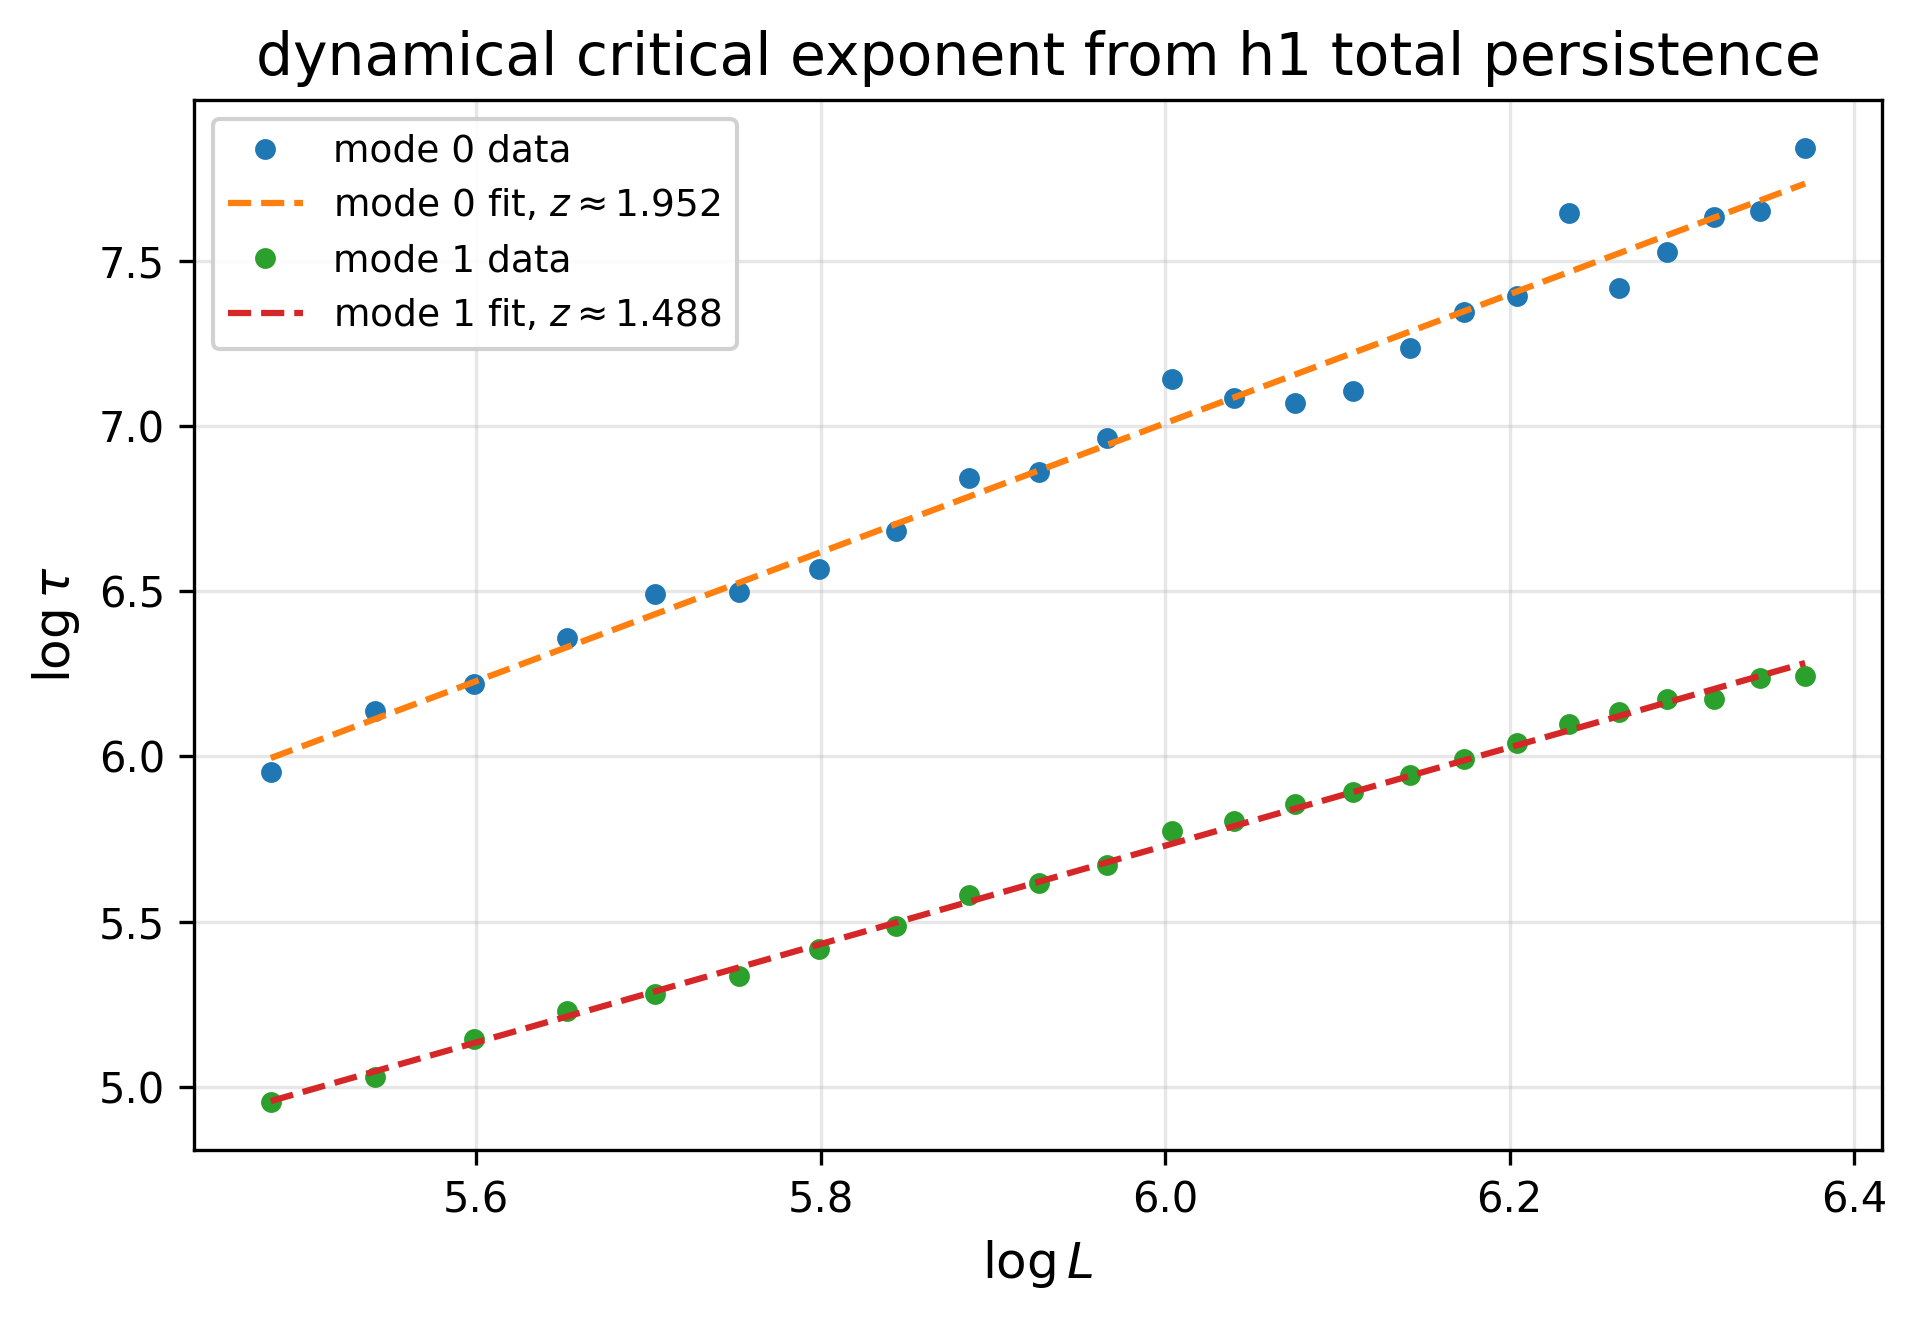

In [23]:
observable_name = "h1_total_persistence_from_points"
process_name = "h1 total persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_0$ Beta Curve Area

The area under the $H_0$ Betti curve measures how many connected components exist across a whole range of filtration scales, instead of looking at just one fixed scale or one lifetime summary. For each filtration value $r$, the $H_0$ Betti number $\beta_\theta(r)$ counts how many connected components are alive at that scale. When $r$ is very small, many points may still be separate, so $\beta_\theta(r)$ can be large. As r grows, nearby components merge, so $\beta_\theta(r)$ decreases. The Betti curve records this count as a function of $r$, and this function computes the area under that curve.

$$A_{\beta_0} = \int_{r_\text{min}}^{r_\text{max}} \beta_0 (r)\,dr$$

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h0_beta_curve_area_notebook.npz
Completed L jobs: 24 / 24
h0_beta_curve_area_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 2.043978054457466
mode 1: z = 1.5039831285579437


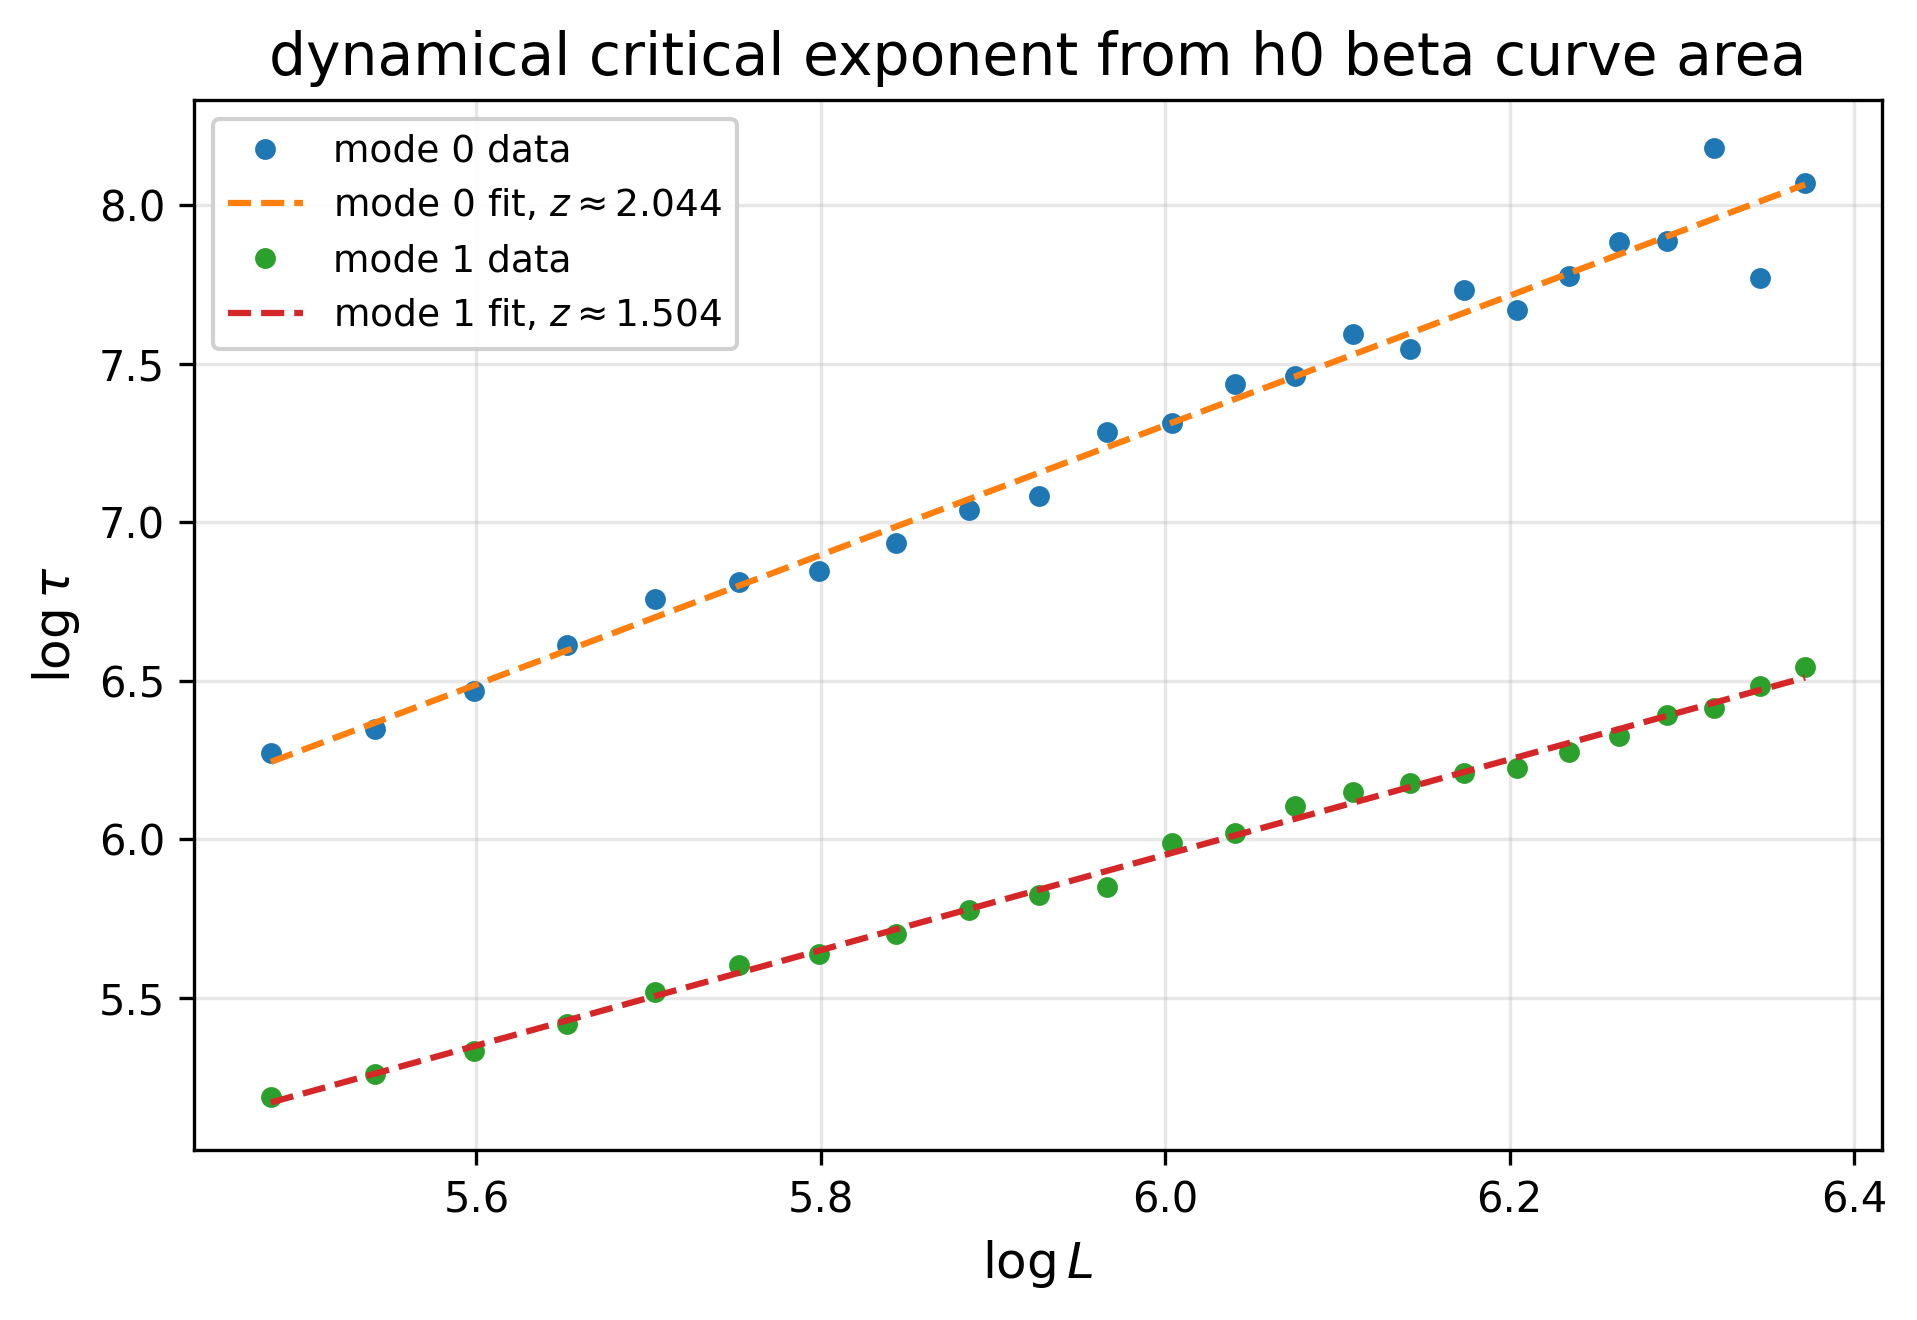

In [24]:
observable_name = "h0_beta_curve_area_from_points"
process_name = "h0 beta curve area"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_0$ CROKER $L^2$ Norm

The $H_0$ CROCKER $L^2$ norm is another way of summarizing the $H_0$ Betti curve, but instead of just taking the area under the curve, it gives more weight to filtration scales where the number of connected components is large. The $H_0$ Betti curve $\beta_\theta(r)$ tells you how many connected components are alive at each filtration scale $r$. The CROCKER $L^2$ norm takes that whole curve, squares its values, integrates over the filtration range, and then takes a square root.

$$\|\beta_0\|_{L^2} = \left(\int_{r_\text{min}}^{r_\text{max}} \beta_0 (r)^2\,dr\right)^\frac12$$

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h0_crocker_l2_norm_notebook.npz
Completed L jobs: 24 / 24
h0_crocker_l2_norm_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 2.00524466369882
mode 1: z = 1.5282682894439243


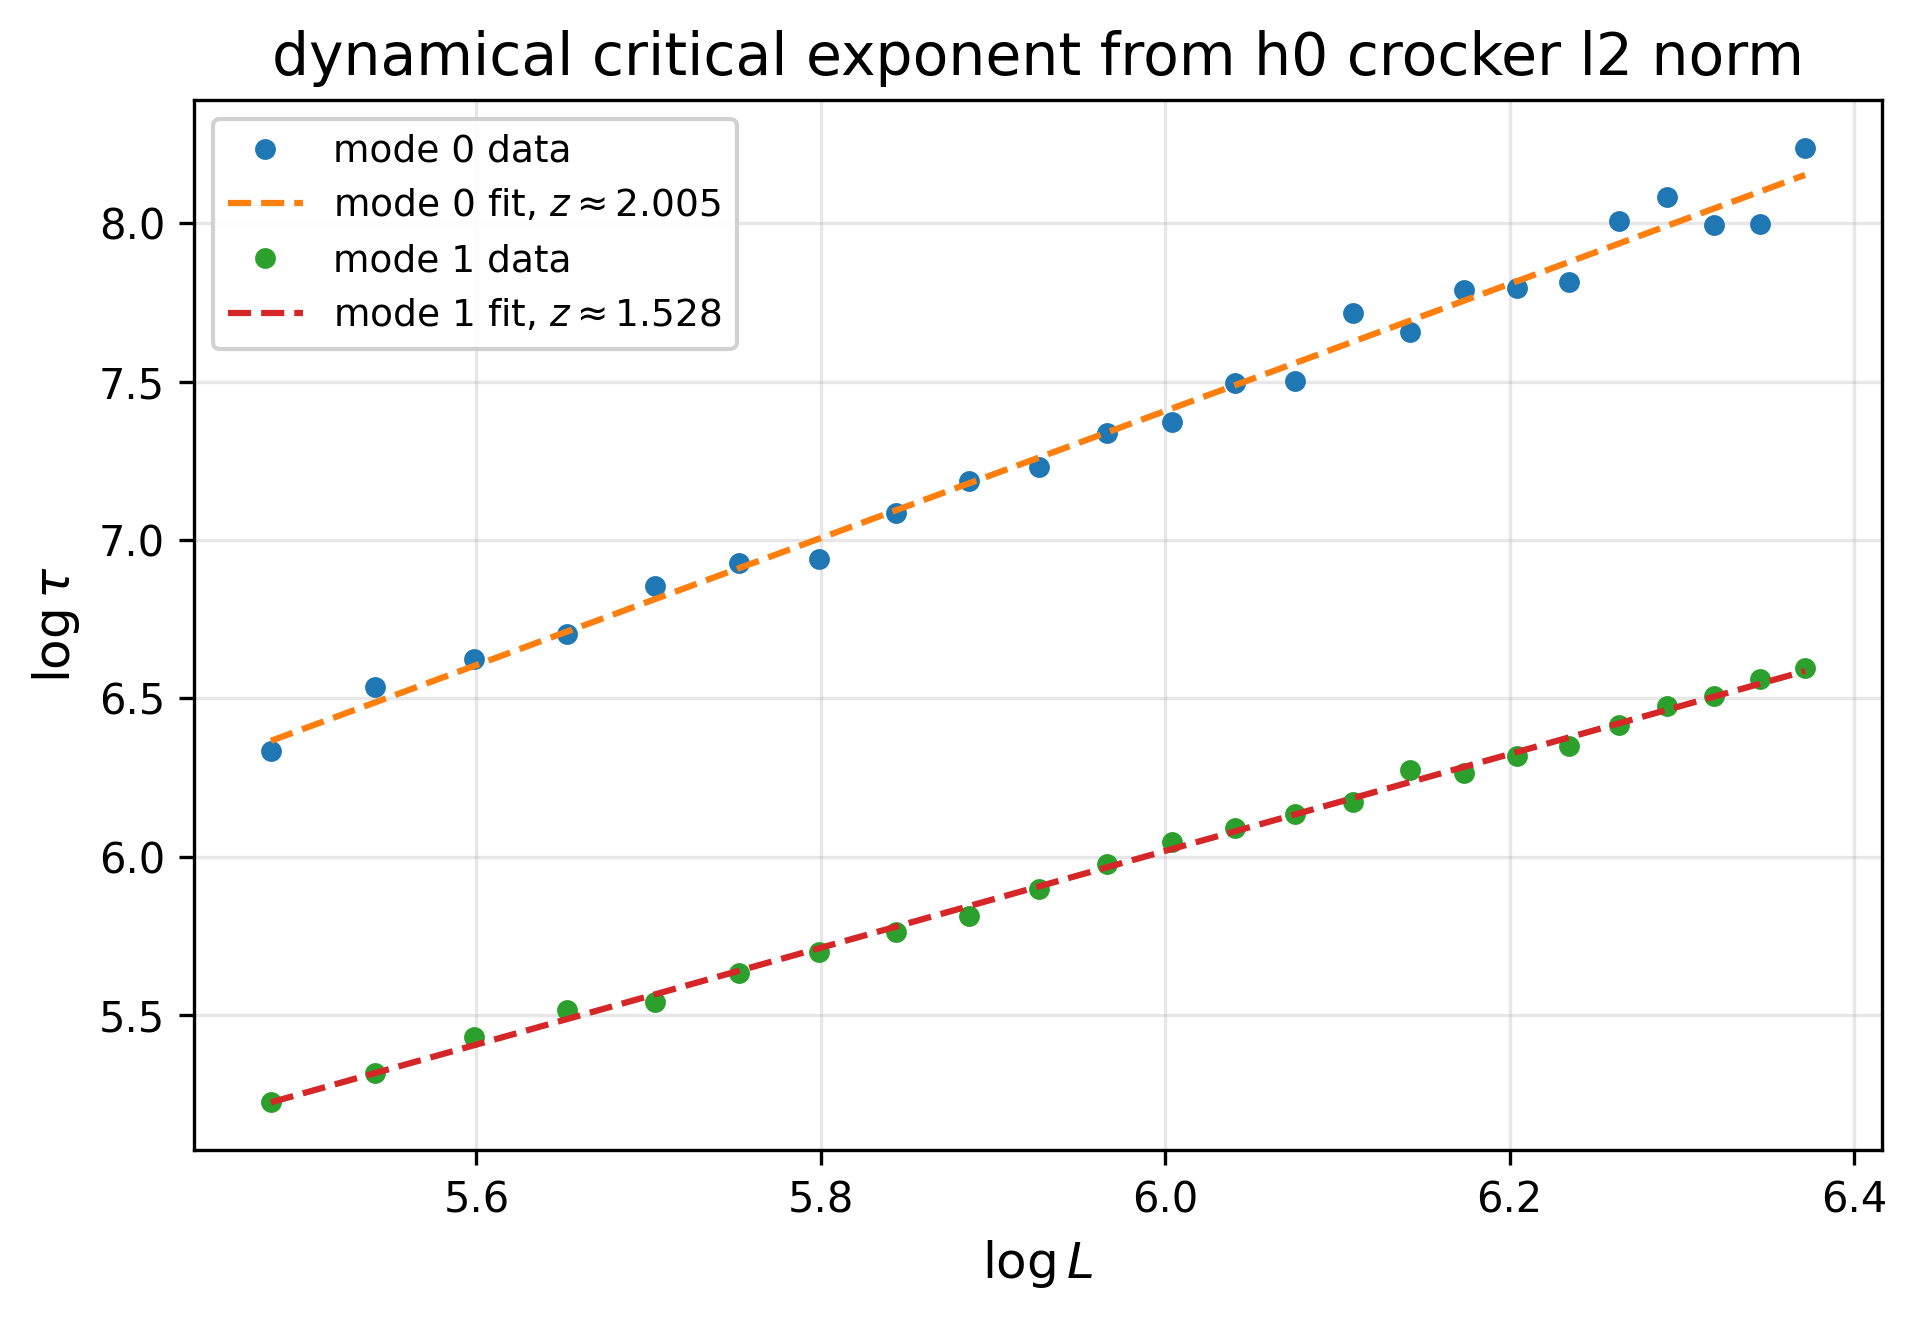

In [25]:
observable_name = "h0_crocker_l2_norm_from_points"
process_name = "h0 crocker l2 norm"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

## Weakly Coupled Topological Observables

### $H_1$ Entropy 

Persistent entropy of finite $H_1$ lifetimes measures how spread out the loop persistence is across the $H_1$ features in the point cloud. First, the code computes the $H_1$ persistence diagram, where each finite $H_1$ lifetime represents how long a loop survives before it gets filled in. Then it adds up all the $H_1$ lifetimes and turns each lifetime into a normalized weight by dividing by the total lifetime. So a long lived loop gets a larger weight, while a short lived loop gets a smaller weight. The entropy is then computed from these weights. If one loop dominates almost all the persistence, the entropy is low. If the persistence is spread more evenly across many loops, the entropy is higher.

$$S_{H_1} = -\sum_{i} p_i \log(p_i), \quad p_i = \frac{l_i}{\sum_{j} l_i} $$

where $l_i = d_i - b_i$ is the finite lifetime of the $i$th $H_1$ feature.

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h1_entropy_notebook.npz
Completed L jobs: 24 / 24
h1_entropy_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.8842023400026648
mode 1: z = 1.3026891706058172


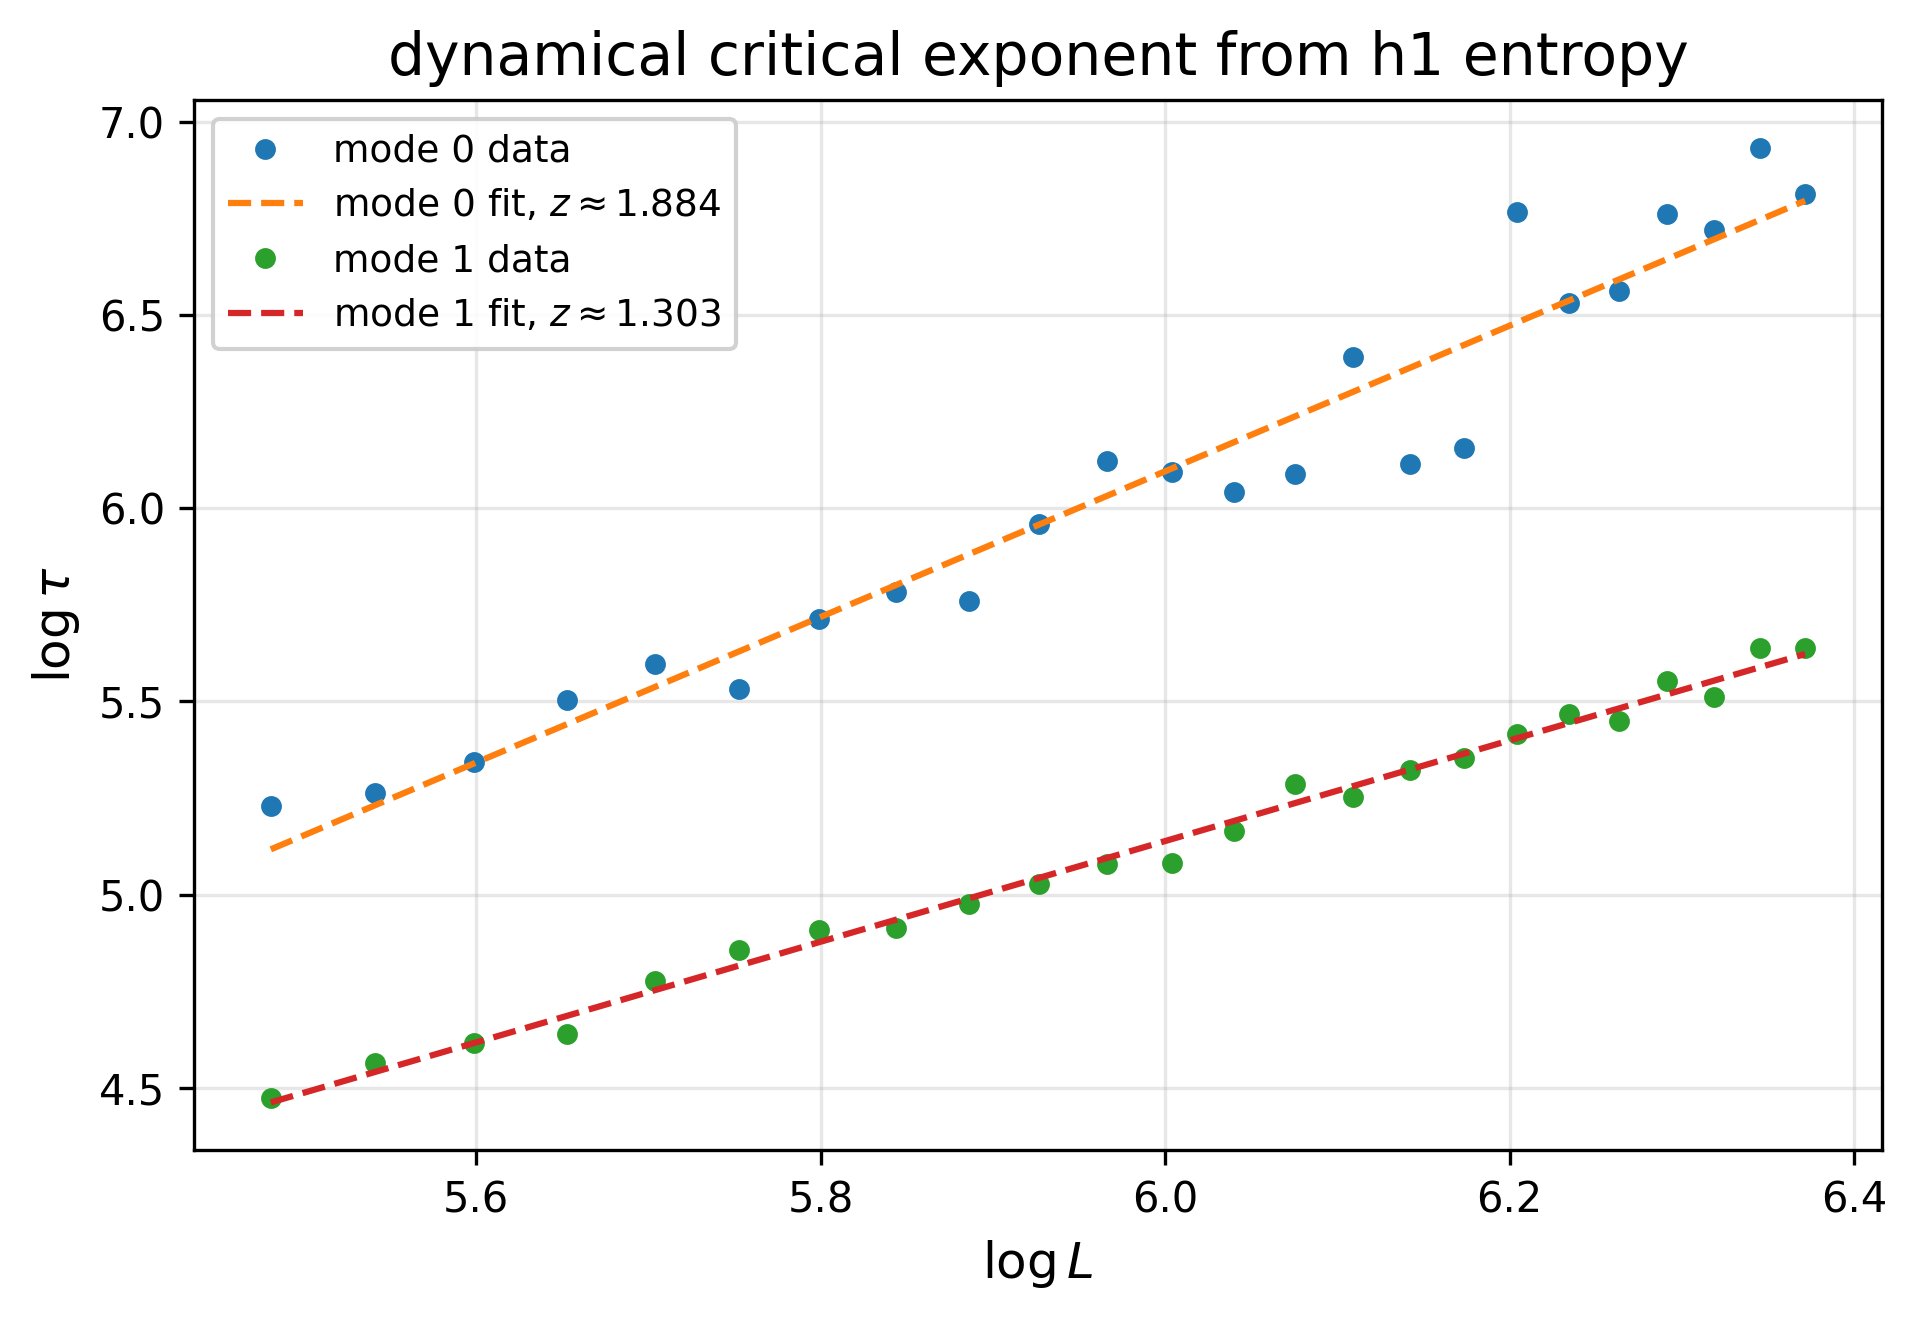

In [26]:
observable_name = "h1_entropy_from_points"
process_name = "h1 entropy"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_1$ Maximum Persistance

Maximum finite $H_1$ persistence picks out the single longest lived loop in the point cloud. Instead of summing all $H_1$ lifetimes or measuring how spread out they are, this observable only asks which loop survived the longest as the filtration scale increased.

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h1_maximum_persistence_notebook.npz
Completed L jobs: 24 / 24
h1_maximum_persistence_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.3266694048791752
mode 1: z = 1.112394923539047


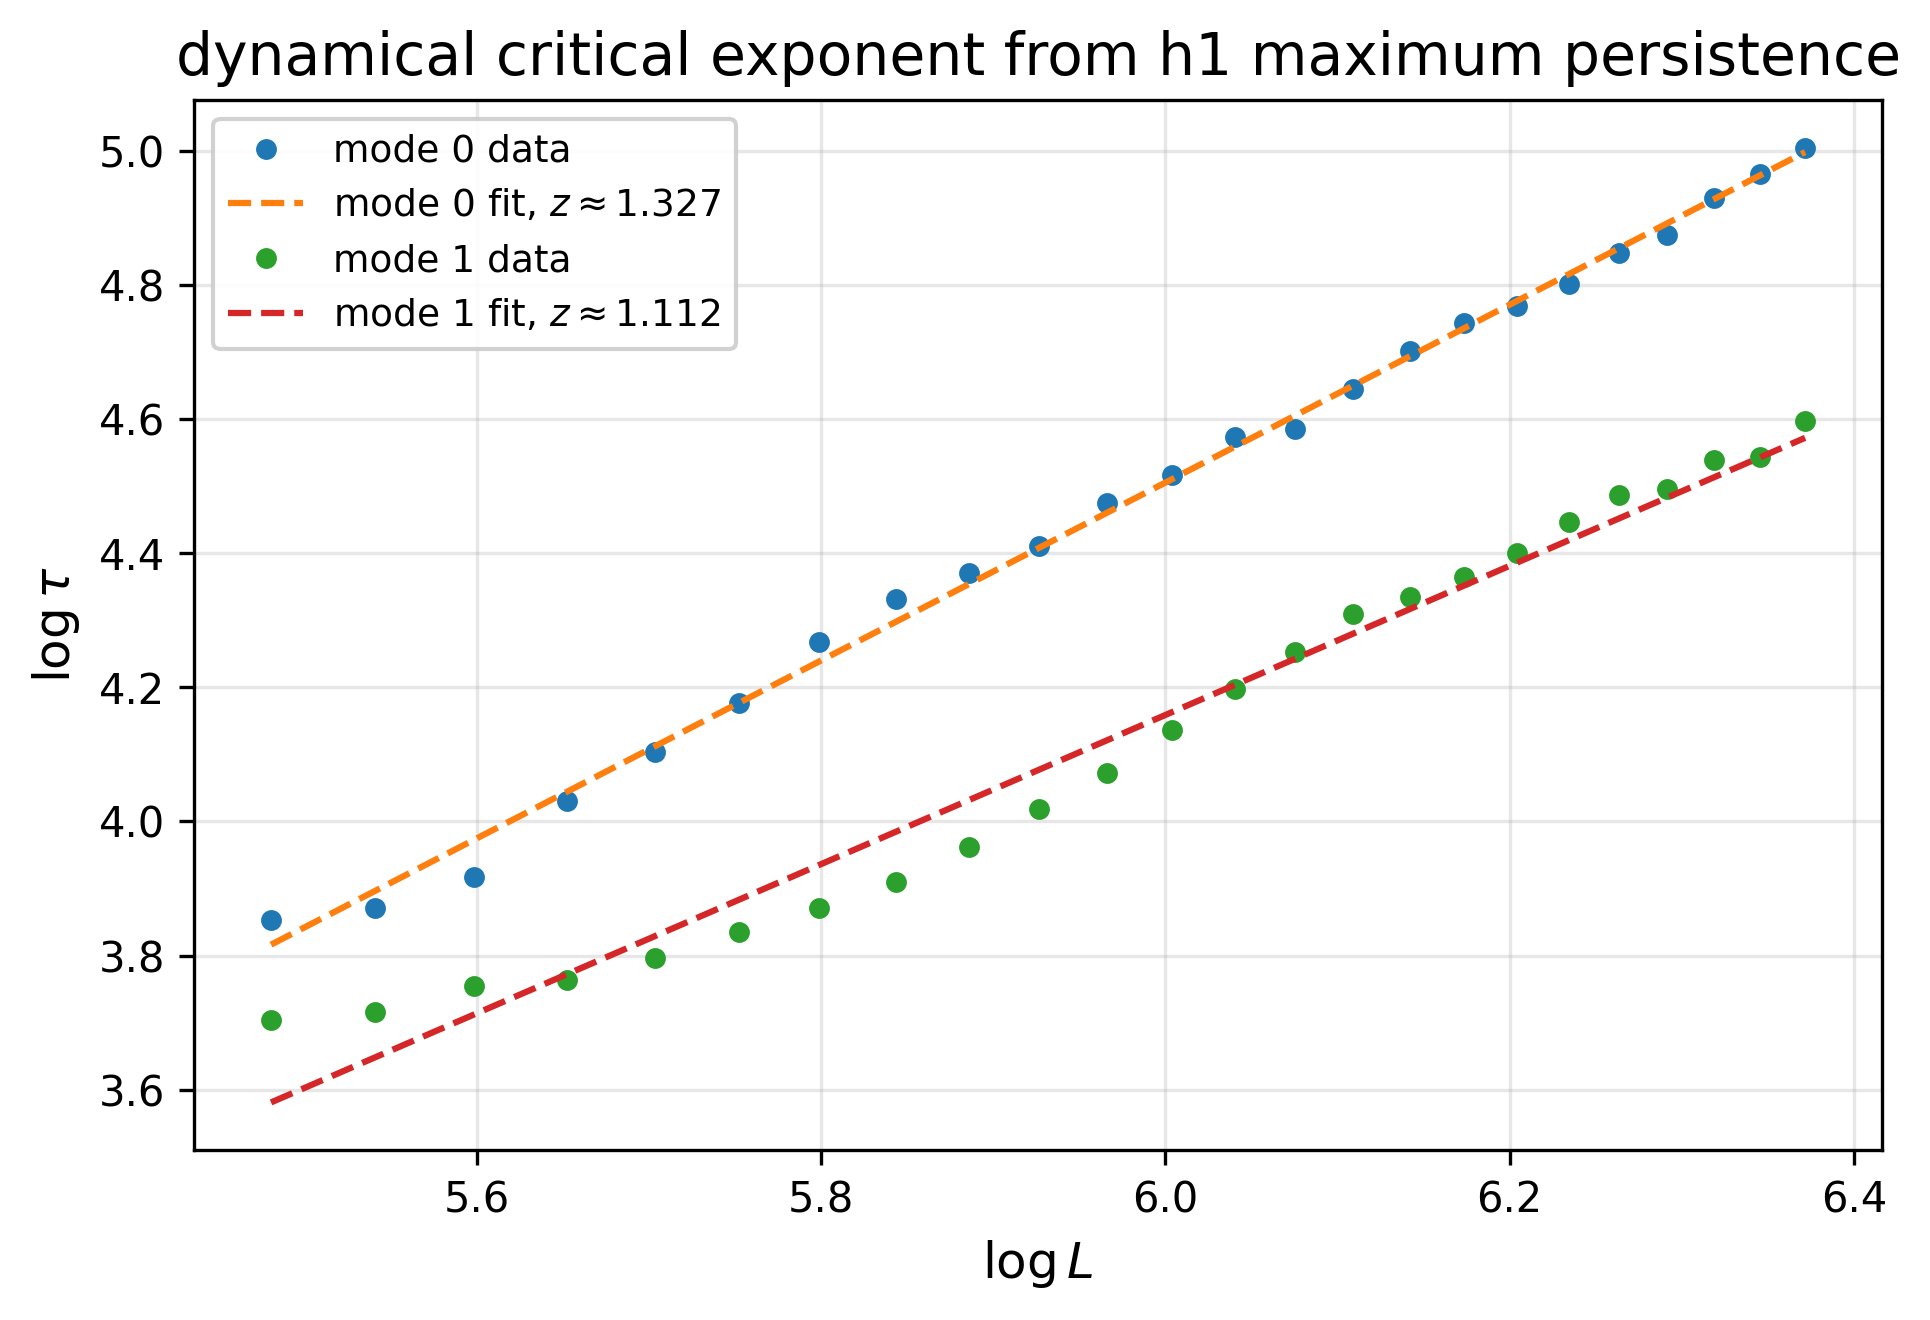

In [27]:
observable_name = "h1_max_persistence_from_points"
process_name = "h1 maximum persistence"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

## Nonlinear/Uncoupled Topological Observables

### $H_0$ Entropy

Persistent entropy of finite $H_0$ lifetimes measures how evenly the connected component persistence is distributed across the point cloud. Each finite $H_0$ lifetime corresponds to a component that eventually merges into another component. The code takes those lifetimes, normalizes them by the total $H_0$ persistence, and treats the normalized values like a probability distribution. If most of the $H_0$ persistence comes from one or two long lived components, the entropy is low. If many components contribute comparable amounts of persistence, the entropy is higher.

$$S_{H_0} = -\sum_{i} p_i \log(p_i), \quad p_i = \frac{l_i}{\sum_{j} l_i}$$

where $l_i = d_i - b_i$ is the finite lifetime of the $i$th $H_0$ feature.

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h0_entropy_notebook.npz
Completed L jobs: 24 / 24
h0_entropy_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.5024219801064307
mode 1: z = 1.5281472773690628


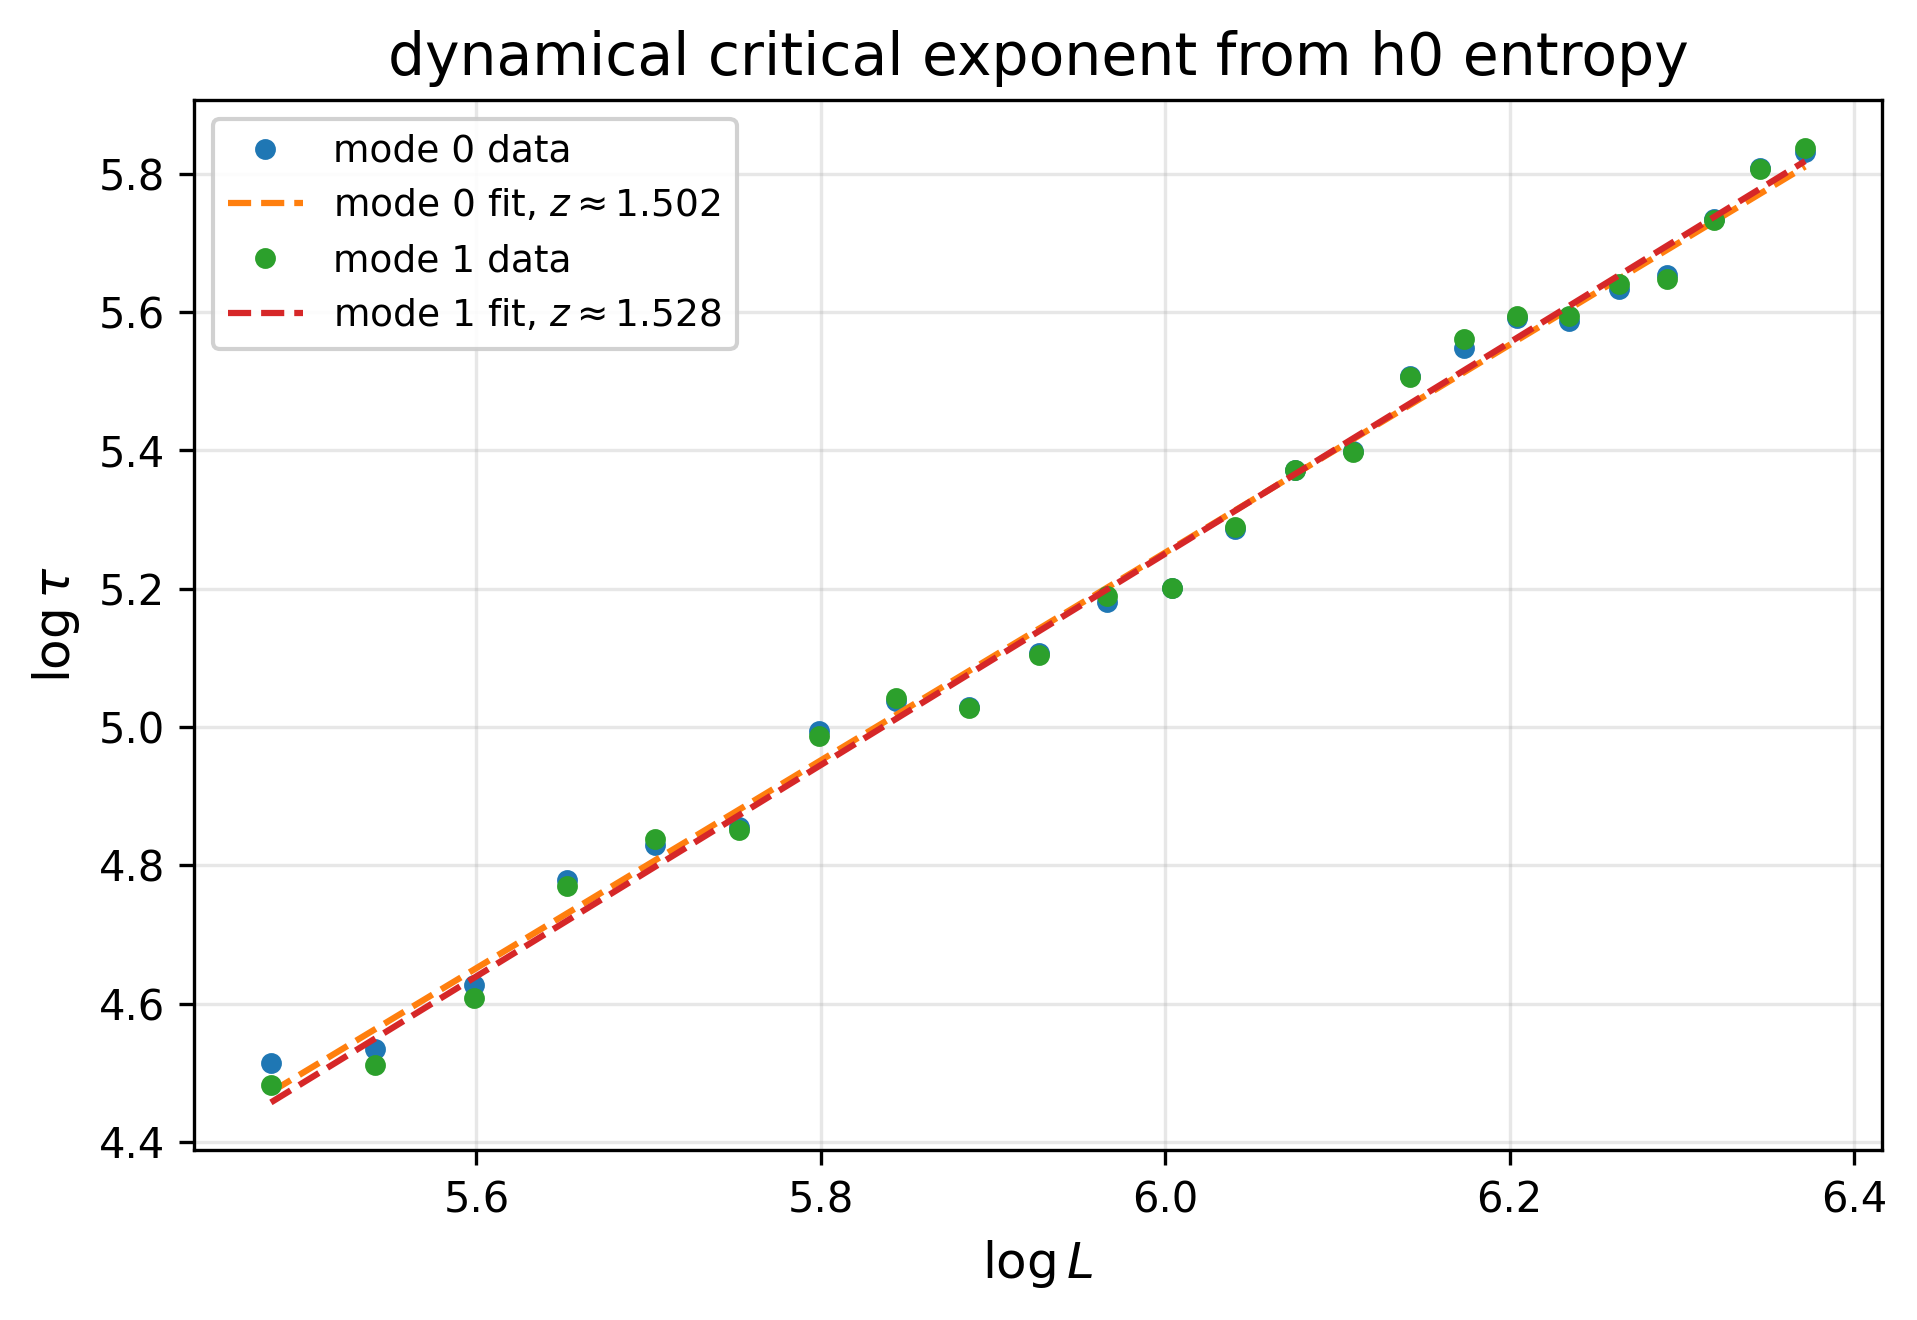

In [28]:
observable_name = "h0_entropy_from_points"
process_name = "h0 entropy"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_1$ Beta Curve Area

The area under the $H_1$ Betti curve summarizes how much loop structure exists across the filtration range. For each filtration scale $r$, the H1 Betti number $\beta_1(r)$ counts how many $H_1$ loops are alive at that scale. Instead of choosing one fixed value of $r$, this observable looks at the whole curve $\beta_1(r)$ and integrates it.

$$A_{\beta_1} = \int_{r_{\text{min}}}^{r_\text{max}} \beta_1(r) \, dr$$

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h1_beta_curve_area_notebook.npz
Completed L jobs: 24 / 24
h1_beta_curve_area_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 2.2340672118747005
mode 1: z = 1.1512603179767593


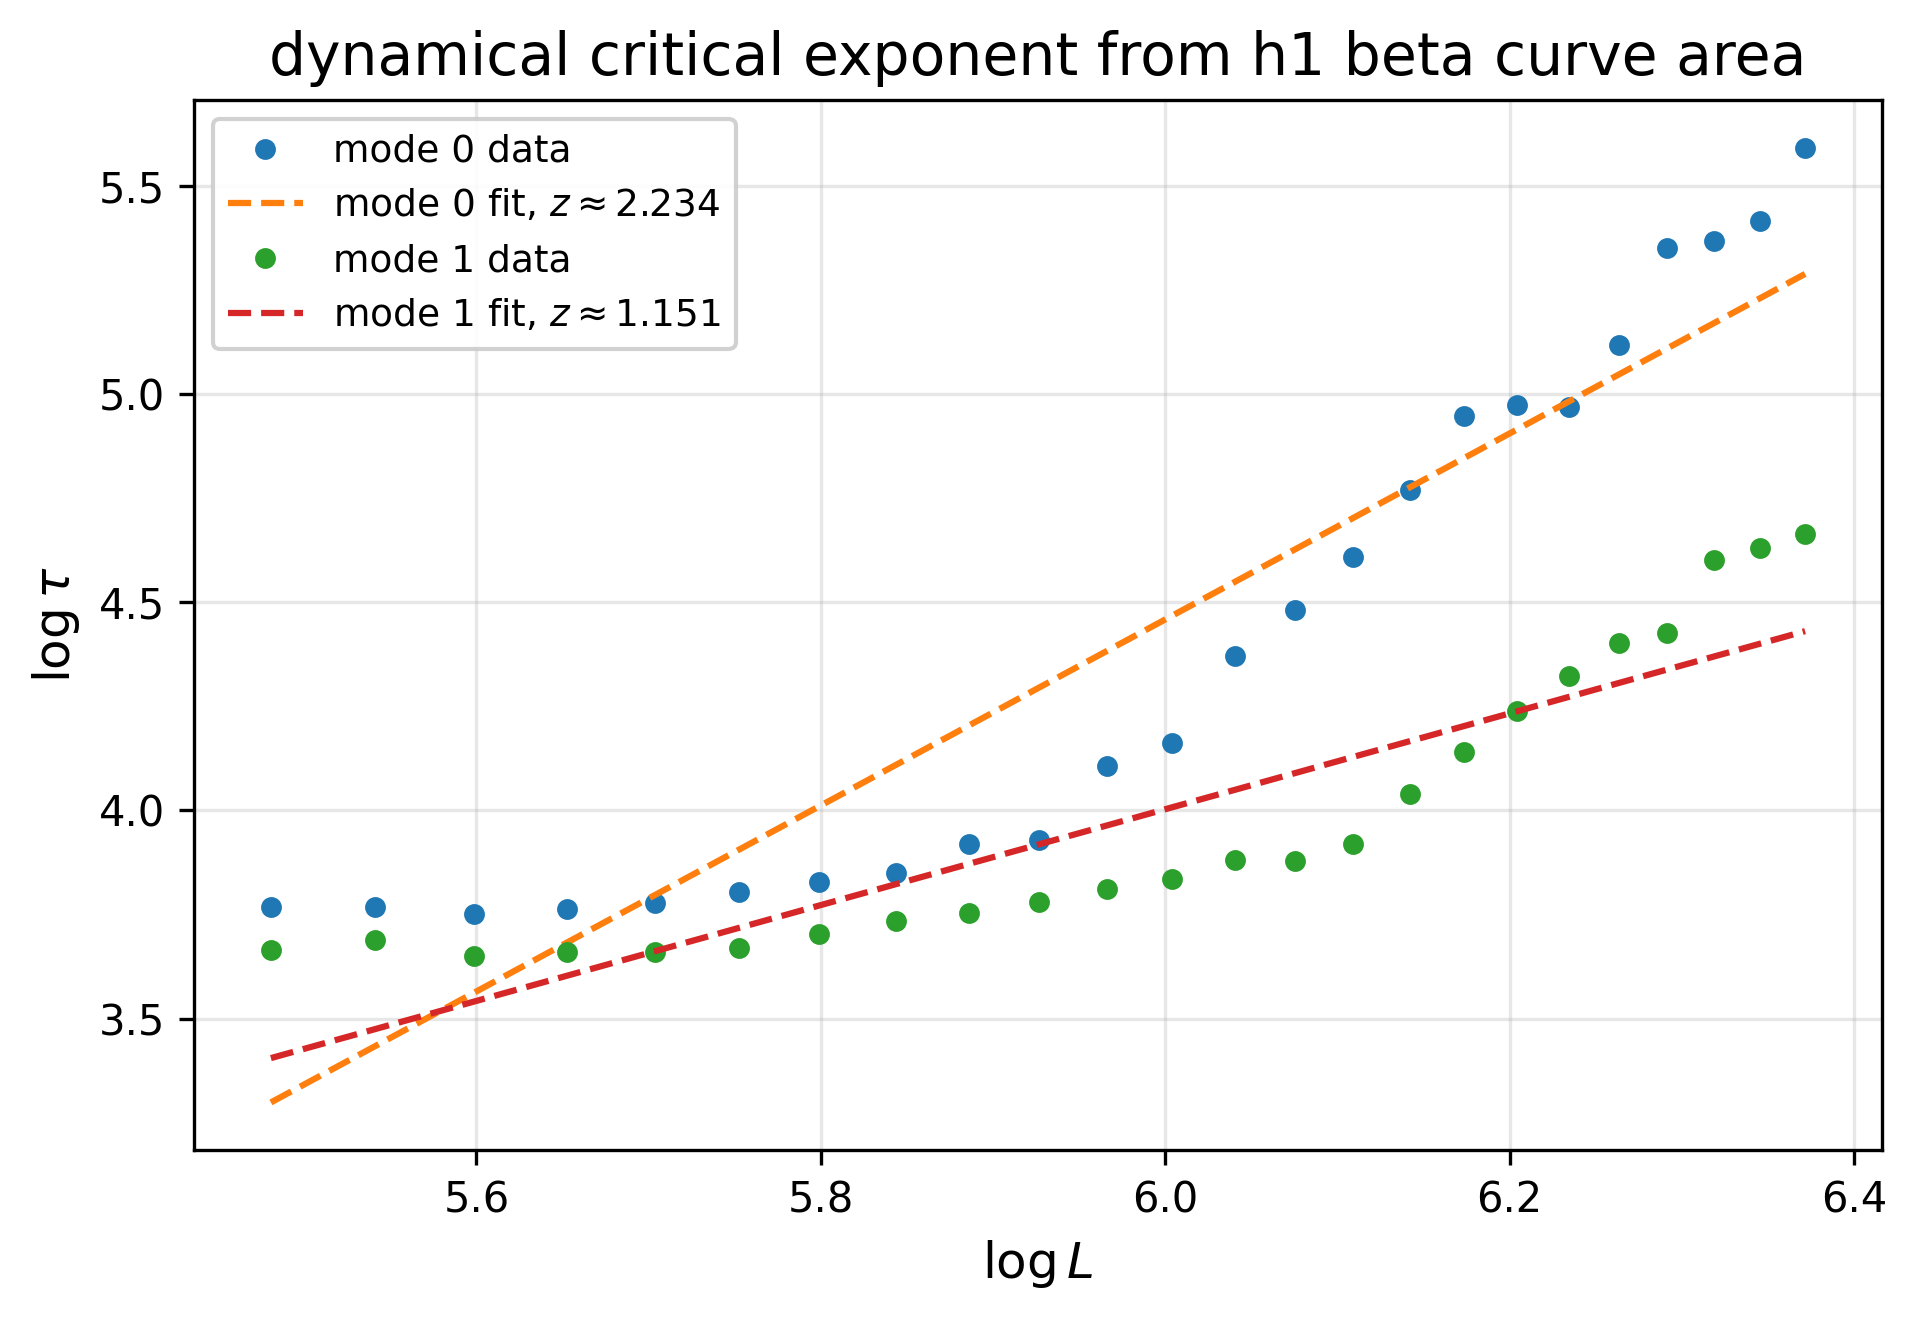

In [29]:
observable_name = "h1_beta_curve_area_from_points"
process_name = "h1 beta curve area"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

### $H_1$ CROKER $L^2$ Norm

The $H_1$ CROCKER $L^2$ norm measures the overall size of the $H_1$ Betti curve, but with extra sensitivity to filtration scales where many loops are alive at the same time. For each scale $r$, $\beta_1(r)$ counts the number of active loop features.

$$\|\beta_1\|_{L^2} = \left(\int_{r_\text{min}}^{r_\text{max}} \beta_1 (r)^2\,dr\right)^\frac12$$

Loaded checkpoint:
   /home/dupreti/TDA-Diffusion-Models/data/slurm_jobs/h1_crocker_l2_norm_notebook.npz
Completed L jobs: 24 / 24
h1_crocker_l2_norm_notebook: 24/24 L jobs complete
all L values already completed; loading taus from checkpoint
mode 0: z = 1.0613168210658959
mode 1: z = 0.39580714485828344


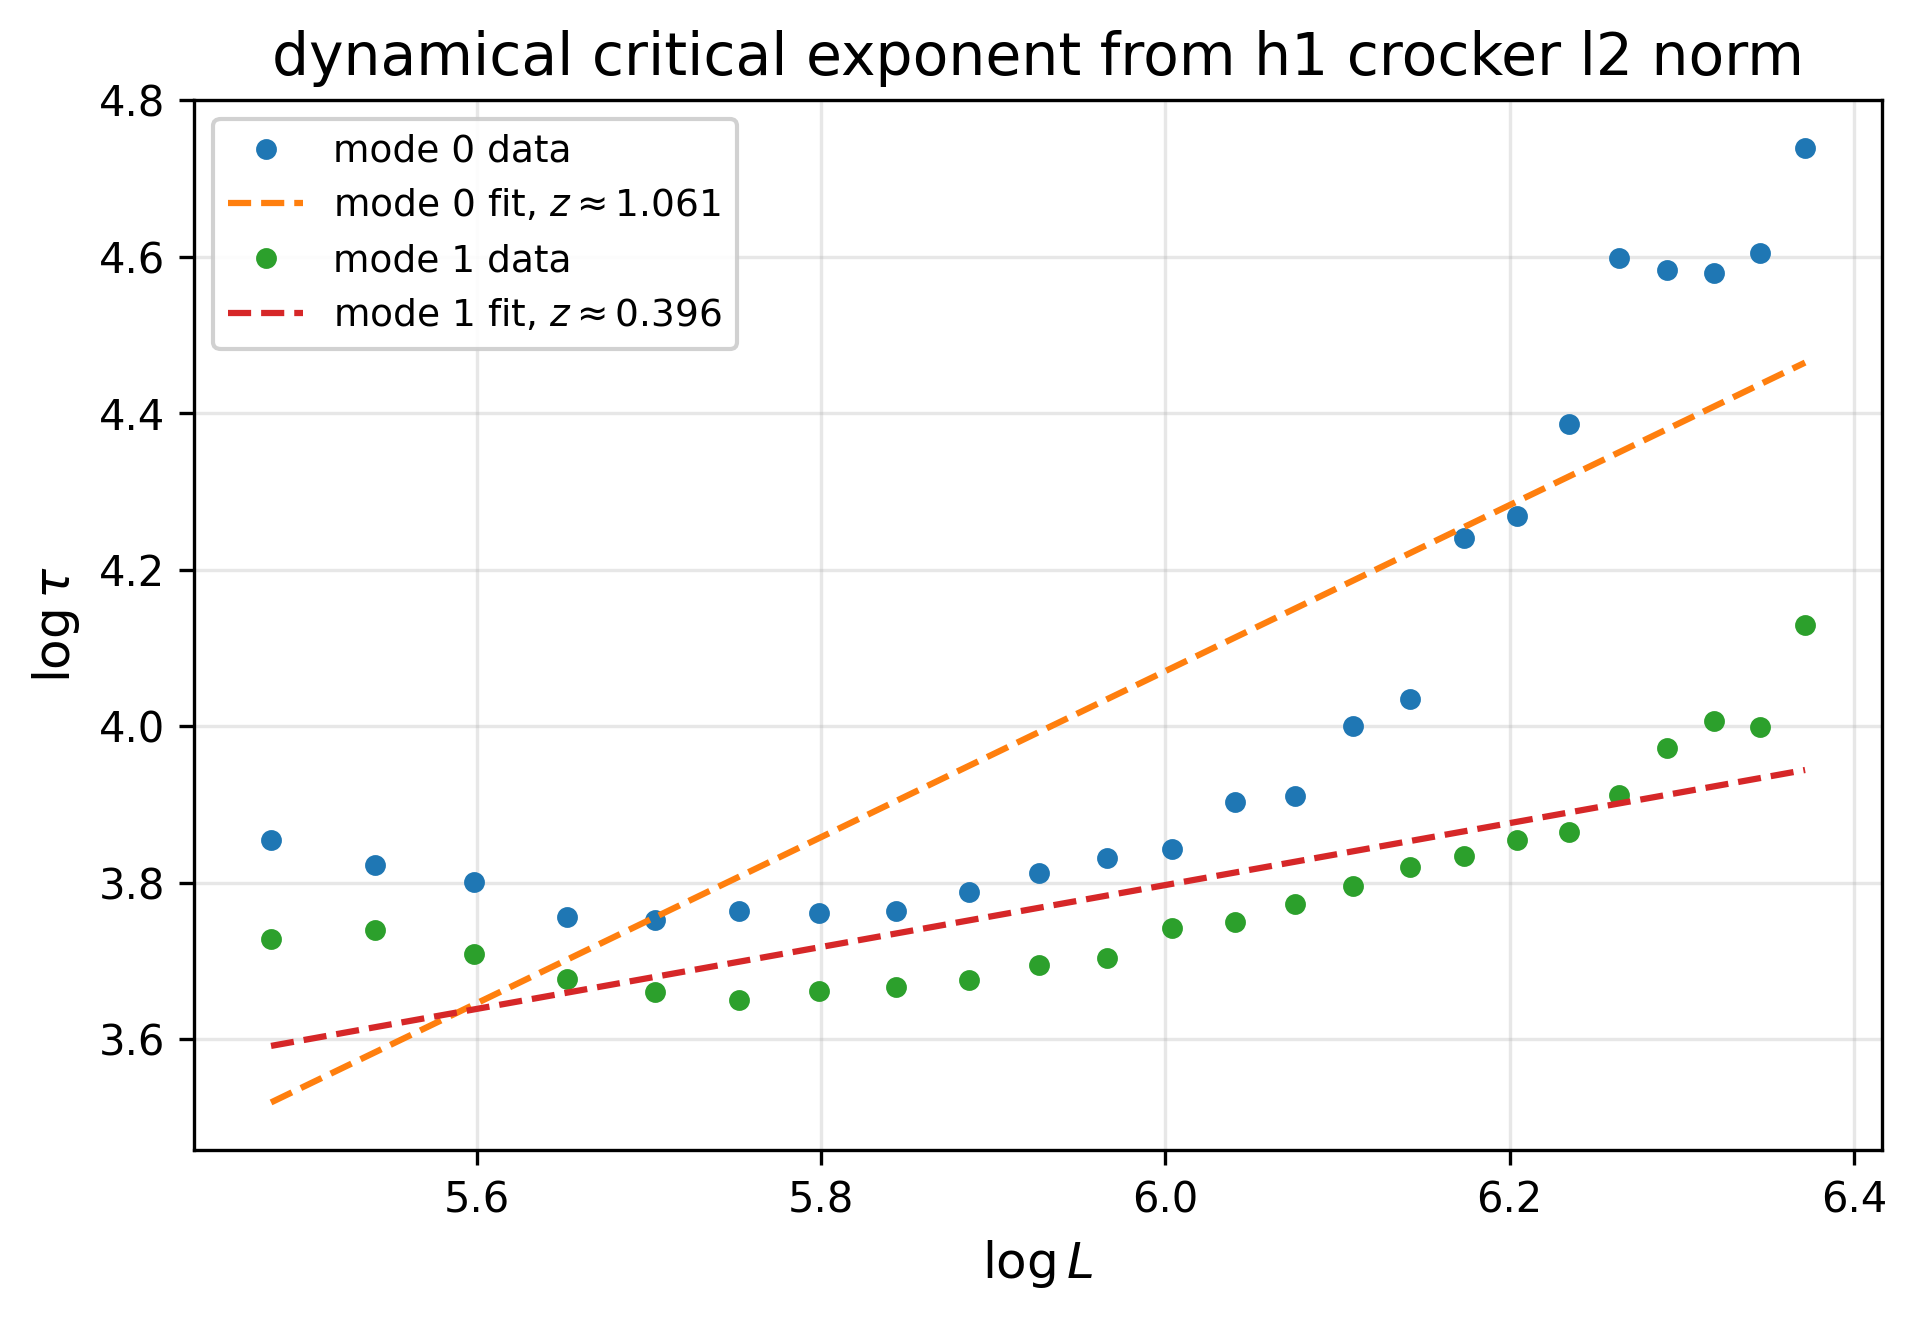

In [30]:
observable_name = "h1_crocker_l2_norm_from_points"
process_name = "h1 crocker l2 norm"

L_values, taus = engine_loop(process_name=process_name, observable_name=observable_name)

plot(L_values, taus, process_name)

## Shutting Down Engines and Slurm Process

Note that automatically killing the kernel will shut down the Slurm process after a few minuets however it is possible to do it from the notebook itself.

This shuts down the IPyParallel controller/engines

In [31]:
rc = ipp.Client(profile="default")
print("Engines before shutdown:", rc.ids)

rc.shutdown(hub=True, block=False)
rc.close()

print("Sent shutdown signal and closed client sockets.")

Engines before shutdown: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Sent shutdown signal to IPyParallel engines and controller.


2026-07-04 10:27:56.331 [task] Unhandled message type: 'shutdown_notification'
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 609, in _handle_events
    self._rebuild_io_state()
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 664, in _rebuild_io_state
    self._update_handler(state)
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py", line 681, in _update_handler
    if state & self.socket.events:
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib/python3.10/site-packages/zmq/sugar/attrsettr.py", line 56, in __getattr__
    return self._get_attr_opt(upper_key, opt)
  File "/home/dupreti/TDA-Diffusion-Models/.venv/lib/python3.10/site-packages/zmq/sugar/attrsettr.py", line 68, in _get_attr_opt
    return self.

The following confirms if the processes are shut down.

In [32]:
cmd = "ps -u $USER -f | grep -E 'ipcontroller|ipengine|ipcluster' | grep -v grep"
result = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

print(result.stdout if result.stdout else "No IPyParallel processes found.")

No IPyParallel processes found.


This shuts down the the Slurm allocation/job

In [33]:
result = subprocess.run("scancel --name=ipengines_tda", shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)

if (result.stdout != ""):
    print("STDOUT:", result.stdout)
    
if (result.stderr != ""):
    print("STDERR:", result.stderr)
    
print("Return code:", result.returncode)

Return code: 0
